In [ ]:
# Where you've uploaded this project's files in your Drive — the rag/ package,
# requirements.txt, and pdfs/. Adjust the path if you put it somewhere else.
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/05-rag'
%cd {PROJECT_DIR}
%pip install -q -r requirements.txt

In [ ]:
# Secrets come from Colab's own manager, not a .env file — click the key icon
# in the left sidebar, add OPENAI_API_KEY and PINECONE_API_KEY once, and they
# persist across sessions without ever being typed into a cell or saved in the
# notebook itself.
#
# MUST run before `from rag import ...` in the next cell — config.py reads
# every setting at import time, so setting these after the import has no effect.
import os
from google.colab import userdata

for name in ("OPENAI_API_KEY", "PINECONE_API_KEY","HF_TOKEN"):
    os.environ[name] = userdata.get(name)

In [4]:
# Import os so we can read and define environment variables used by the ingestion pipeline.
import os

# Define the default target size for chunks when the caller has not configured it elsewhere.
# This value is measured in tokens, not characters.
os.environ.setdefault("CHUNK_TOKEN_TARGET", "1024")

# Define the minimum fraction of a page that an extracted figure should occupy to be retained.
os.environ.setdefault("FIGURE_AREA_THRESHOLD", "0.01")

# Define the directory where extraction and ingestion reports should be written.
os.environ.setdefault("REPORT_DIR", "/content/reports")


'reports'

In [ ]:
os.environ.setdefault("TABLE_CELL_MATCHING", "1")

# Define the minimum fraction of a page that an extracted figure should occupy to be retained.
os.environ.setdefault("MIN_CHUNK_TOKENS", "150")

# Define the directory where extraction and ingestion reports should be written.
os.environ.setdefault("FIX_HEADING_HIERARCHY", "1")

In [5]:
# Import Path so PDF paths can be handled consistently across operating systems.
from pathlib import Path

# Import the ingestion modules that contain configuration, parsing, chunking, and table helpers.
from rag import chunking, clients, config, docling_io, tables

# Point the notebook at the PDF that will be parsed and ingested.
SOURCE_PDF = Path("pdfs/AI-Enablers-Adopters-research-report.pdf")

# Set this to a cloud bucket name when figure images and parse artifacts should be shared remotely.
# None means that figure images and cache artifacts remain local.
BUCKET = None

# Create a stable document identifier from the PDF filename.
# This identifier is later stored in record metadata and used to scope record IDs.
DOC_ID = config.slugify(SOURCE_PDF.stem)

# Print the key configuration values so the run can be verified before processing starts.
print(f"document   : {DOC_ID}")
print(f"embedding  : {config.EMBED_MODEL} ({clients.EMBED_DIMS}d)")
print(f"chunk size : {config.CHUNK_TOKENS} tokens")
print(f"vision     : {config.VISION_MODEL}")
print(f"reports    : {config.REPORT_DIR.resolve()}")


document   : ai-enablers-adopters-research-report
embedding  : text-embedding-3-small (1536d)
chunk size : 1024 tokens
vision     : gpt-4o-mini
reports    : /Users/akellaprudhvi/PycharmProjects/vs-langchain-agents/05-rag/reports


In [6]:
# Parse the source PDF with the project's Docling-based parser.
# The result is the structured document object used by all later ingestion stages.
doc = docling_io.parse_pdf(SOURCE_PDF)


  enrichments ON : do_code_enrichment, do_formula_enrichment, do_ocr, do_picture_classification, generate_picture_images, generate_table_images
  enrichments OFF: do_chart_extraction, do_picture_description, enable_remote_services
  (do_picture_description and enable_remote_services are off on purpose — describe_figures() runs after the parse, cached)
  pipeline options in effect:
    do_ocr                        True
    do_table_structure            True
    do_picture_classification     True
    do_formula_enrichment         True
    do_code_enrichment            True
    generate_picture_images       True
    generate_table_images         True
    do_picture_description        False
    enable_remote_services        False
    images_scale                  2.0
    table mode                    TableFormerMode.ACCURATE
    do_cell_matching              True
    layout model                  layout_heron
    layout score_threshold        0.3
    create_orphan_clusters        True
   

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

[INFO] 2026-09-03 07:49:15,841 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-09-03 07:49:15,850 [RapidOCR] download_file.py:60: File exists and is valid: /Users/akellaprudhvi/PycharmProjects/vs-langchain-agents/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-09-03 07:49:15,851 [RapidOCR] main.py:63: Using /Users/akellaprudhvi/PycharmProjects/vs-langchain-agents/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-09-03 07:49:15,867 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-09-03 07:49:15,869 [RapidOCR] download_file.py:60: File exists and is valid: /Users/akellaprudhvi/PycharmProjects/vs-langchain-agents/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-03 07:49:15,870 [RapidOCR] main.py:63: Using /Users/akellaprudhvi/PycharmProjects/vs-langchain-agents/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie model.text_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


  parsed in 16s  (2s per page)
  confidence: mean=QualityGrade.EXCELLENT low=QualityGrade.GOOD
  NOTE: 1 page(s) below GOOD, worth a manual look: p3 (FAIR)
  figures described: 16 (16 from cache, 0 model calls), 1 below the area floor


In [7]:
# Export the parsed document to markdown once.
# Rendering the entire document can be expensive, especially for long PDFs,
# so the markdown is reused for both inspection and the document-date heuristic.
markdown = doc.export_to_markdown()

# Infer the document's publication/report date from the first 4,000 characters of the document.
# This is intentionally separate from the ingestion timestamp.
doc_date = chunking.document_date(SOURCE_PDF, markdown[:4000])

# Print basic parsing/date information so the run can be sanity-checked.
print(f"pages {len(doc.pages)}   document date {doc_date}")


pages 7   document date 2025


In [8]:
# Import the heading-cleaning pass that runs before HybridChunker.
# It corrects SectionHeaderItems that are actually captions, sentence fragments,
# overly long sentence-like text, or labels inside exhibits.
from rag.headings import clean_headings

# Mutate the parsed document so false headings become ordinary TextItems.
# This must happen before HybridChunker because headings determine chunk boundaries.
clean_headings(doc)


  demoted 5 false heading(s):
    'Exhibit 6:' — a numbered label, not a section
    'Al Agent Infrastructure' — a label inside an exhibit, not a section
    'Al Agent Vendors' — a label inside an exhibit, not a section
    'Please click here for the full excel database of >3,700 stocks mapped ' — ends like a sentence
    'through 2024.' — ends like a sentence
  11 heading(s) remain


[('Exhibit 6:', 'a numbered label, not a section'),
 ('Al Agent Infrastructure', 'a label inside an exhibit, not a section'),
 ('Al Agent Vendors', 'a label inside an exhibit, not a section'),
 ('Please click here for the full excel database of >3,700 stocks mapped ',
  'ends like a sentence'),
 ('through 2024.', 'ends like a sentence')]

In [ ]:
from rag import inspect as inspection
report = inspection.inspect(doc, markdown)

In [ ]:
report_path = inspection.write_extraction_report(doc, DOC_ID, SOURCE_PDF)

In [9]:
# Import the configured chunk-token target.


# Import the tokenizer encoding used by the embedding model.
from rag.config import ENCODING

# Import Docling's HybridChunker, which performs structure-aware and token-budget chunking.
from docling.chunking import HybridChunker

# Import the serializer classes needed to customize how document elements are serialized.
from docling_core.transforms.chunker.hierarchical_chunker import (
    ChunkingDocSerializer, ChunkingSerializerProvider,
)

# Import the tokenizer adapter used by HybridChunker.
from docling_core.transforms.chunker.tokenizer.openai import OpenAITokenizer

# Import a serializer that preserves table structure as markdown.
from docling_core.transforms.serializer.markdown import MarkdownTableSerializer


# Define a custom serializer provider so tables are serialized as markdown during chunking.
class MarkdownTableProvider(ChunkingSerializerProvider):
    # HybridChunker calls get_serializer with "doc" as a keyword argument,
    # so the parameter name must remain exactly "doc".
    # **kwargs makes the provider tolerant of additional arguments in future Docling versions.
    def get_serializer(self, doc, **kwargs):
        # Build the serializer for this document and explicitly use markdown for tables.
        return ChunkingDocSerializer(
            doc=doc, table_serializer=MarkdownTableSerializer())


In [10]:
from rag.config import CHUNK_TOKENS

# Create the HybridChunker using the embedding model's tokenizer and the configured token budget.
chunker = HybridChunker(
    # Use the same tokenizer encoding as the embedding model so token counts match embedding limits.
    tokenizer=OpenAITokenizer(tokenizer=ENCODING, max_tokens=CHUNK_TOKENS),

    # Use the custom provider so table content is represented as markdown rather than flattened text.
    serializer_provider=MarkdownTableProvider(),

    # Disable Docling's peer merging because this project performs its own type-aware prose merging later.
    merge_peers=False,
)


In [11]:
# Run HybridChunker over the cleaned document.
# The result is converted to a list because the later passes iterate over the chunks multiple times.
chunks = list(chunker.chunk(dl_doc=doc))


In [12]:
# Extract and persist figure images associated with the parsed document.
# The returned dictionary maps Docling picture references to stored image URIs.
uris = docling_io.save_figures(doc, DOC_ID, BUCKET)

# Report how many figure images were successfully stored.
print(f"{len(uris)} figure images stored")


0 figure images stored


# _to_entries workflow
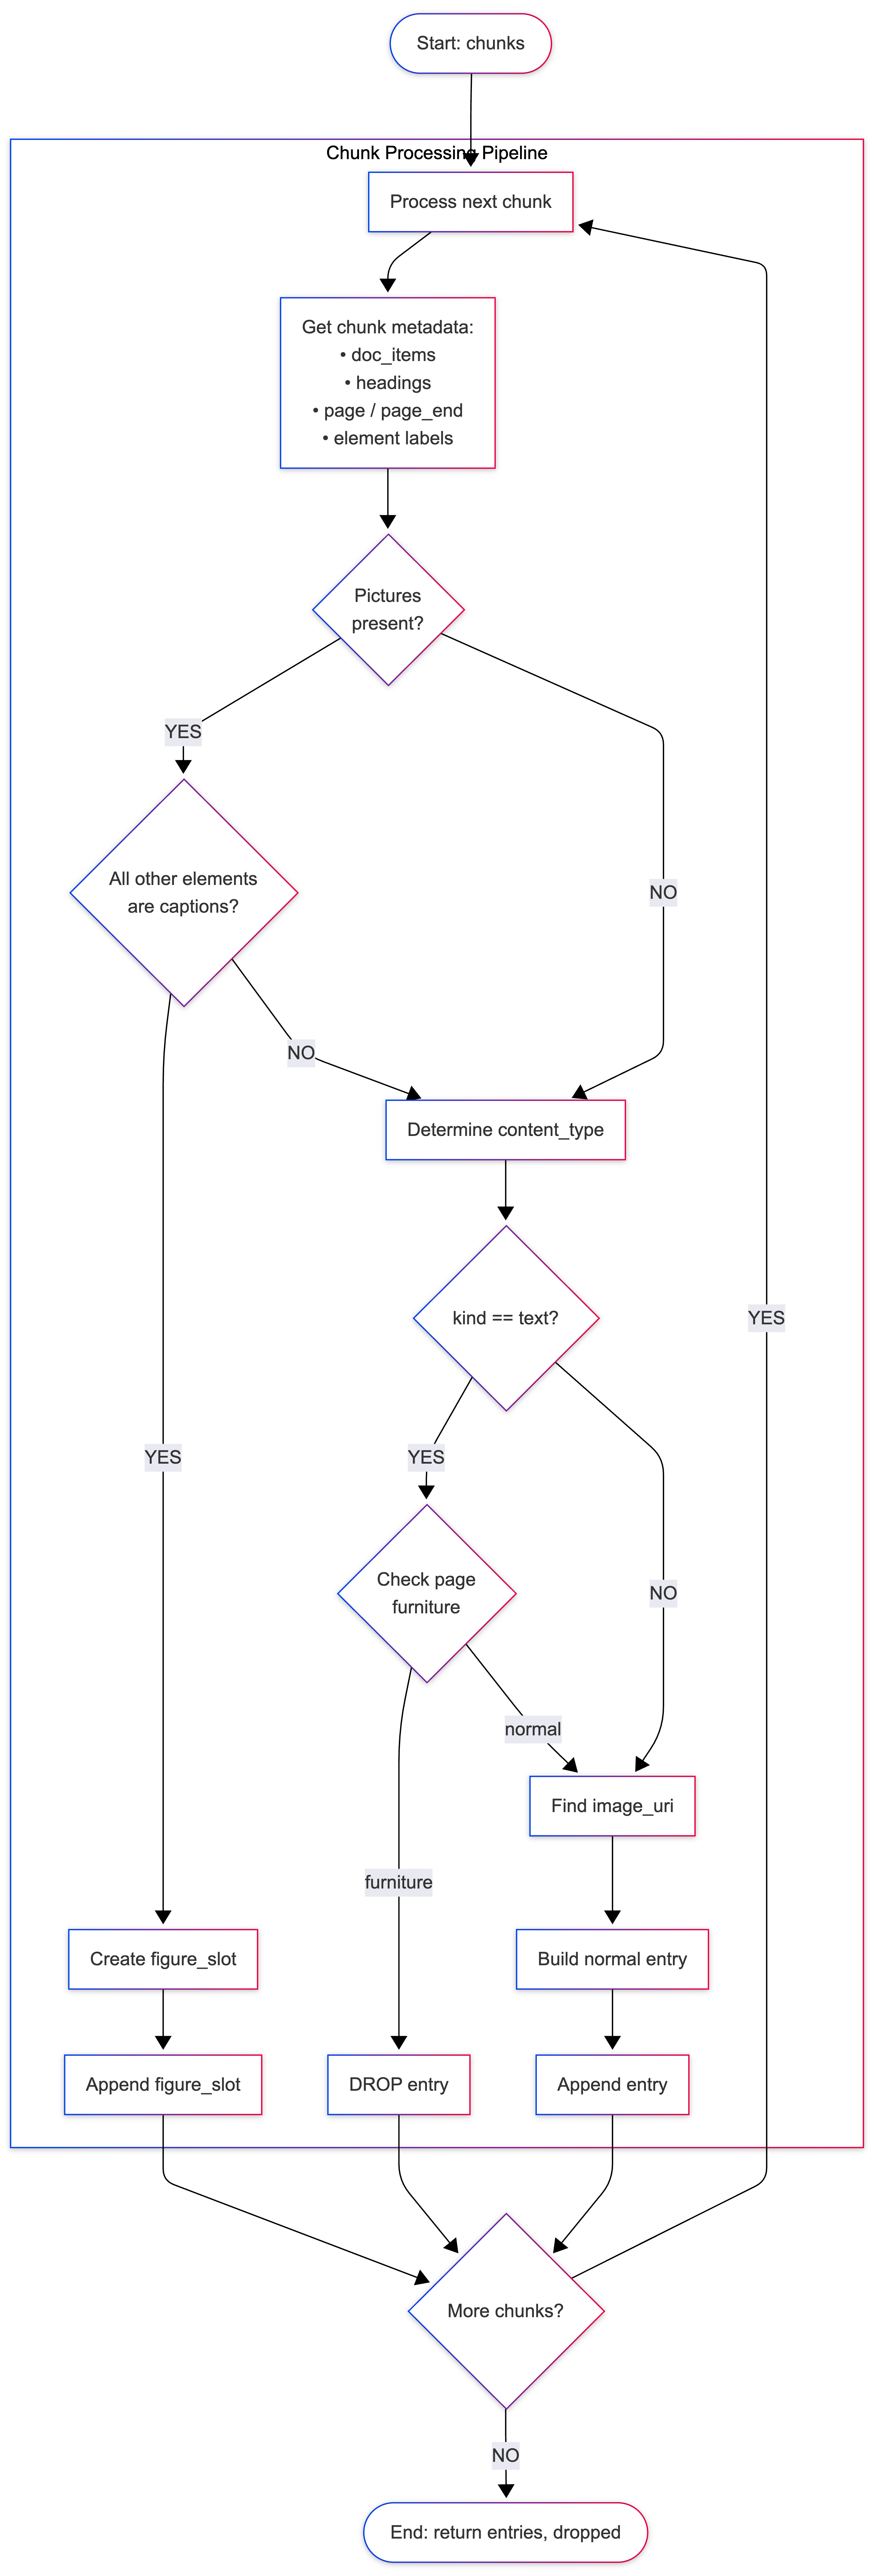

----

## is_funiture workflow

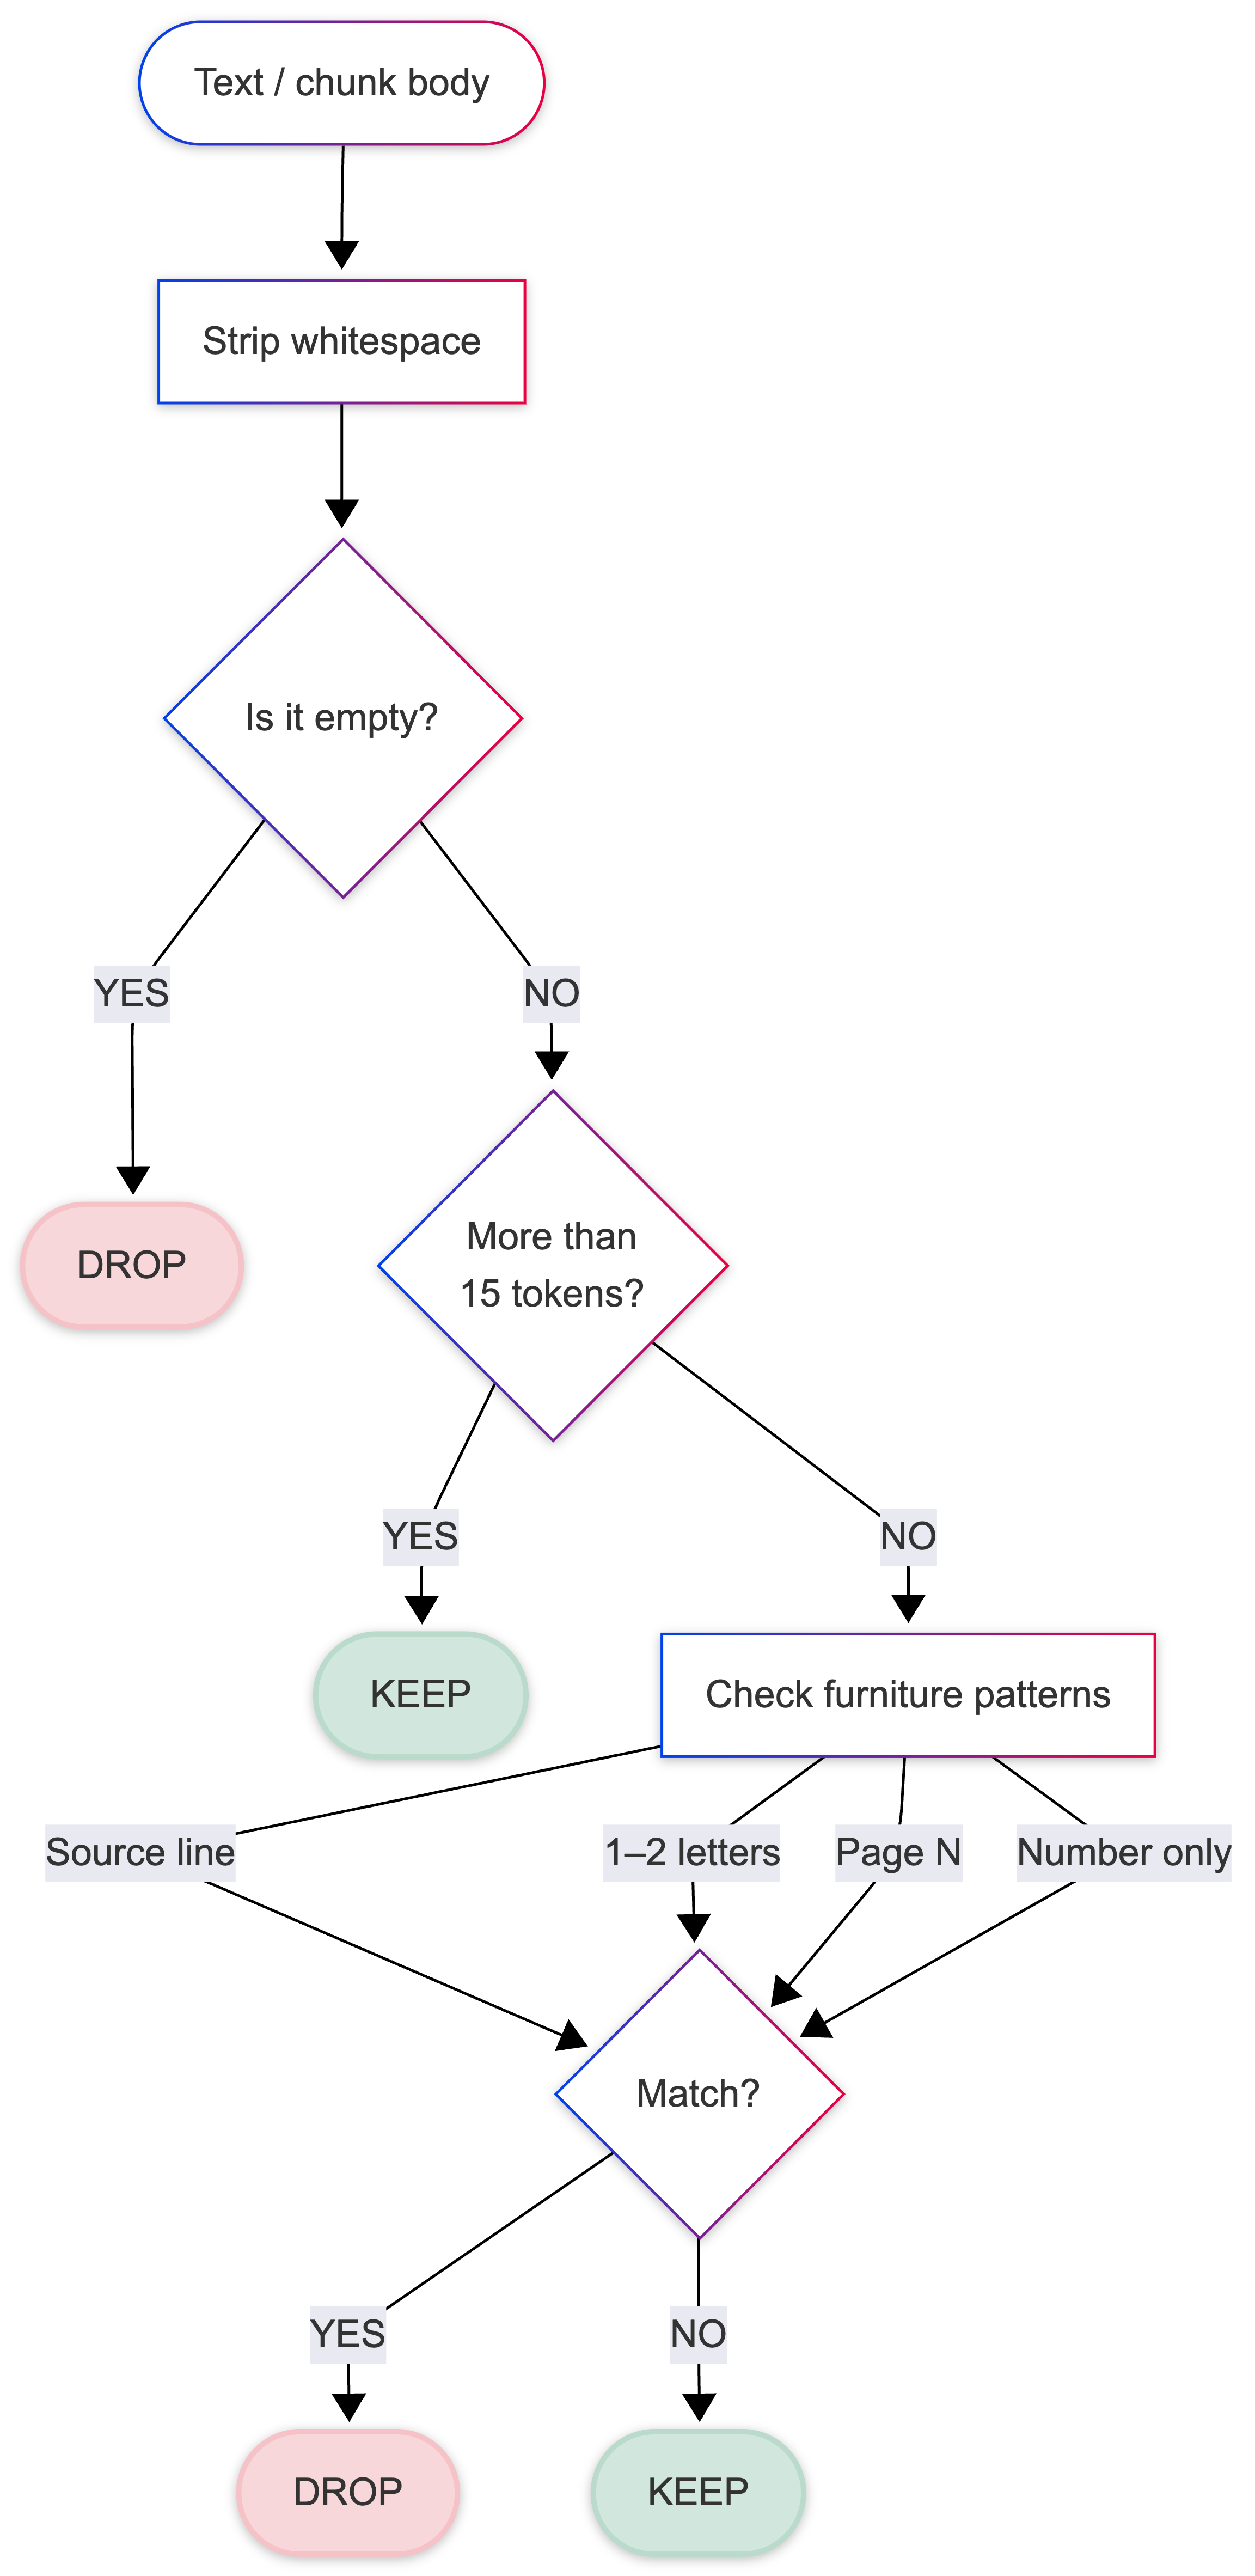

| Priority | Rule | Pattern | Example | Result |
| --- | --- | --- | --- | --- |
| 1 | Empty | `^\s*$` | `""` | ❌ Drop |
| 2 | Too large | > 15 tokens | Long paragraph | ✅ Keep |
| 3 | Source line | `^sources?\s*:` | Source: Bloomberg | ❌ Drop |
| 4 | Single glyph | `^[A-Za-z]{1,2}$` | A, M, AI | ❌ Drop |
| 5 | Page marker | `^page\s+\d+\b` | Page 10 | ❌ Drop |
| 6 | Bare number | `^\d{1,3}$` | 10, 25 | ❌ Drop |
| — | No match | — | Normal paragraph | ✅ Keep |

In [13]:
# Import the first project-specific chunking pass.
from rag.chunking import _to_entries

# Convert Docling chunks into lightweight entries.
# This pass classifies content, removes small page-furniture text, and marks figure-only chunks as figure slots.
"""
chunks
   ↓
HybridChunker output

chunker
   ↓
used to recreate contextualized text

figure_uris
   ↓
mapping of Docling picture refs → stored image URI
"""
entries, dropped = _to_entries(chunks, chunker, uris)


# _merge_prose workflow

- The purpose of _merge_prose() is to combine small/consecutive text chunks that belong to the same section, while making sure that tables, figures, and other non-prose content are not incorrectly merged into the text.

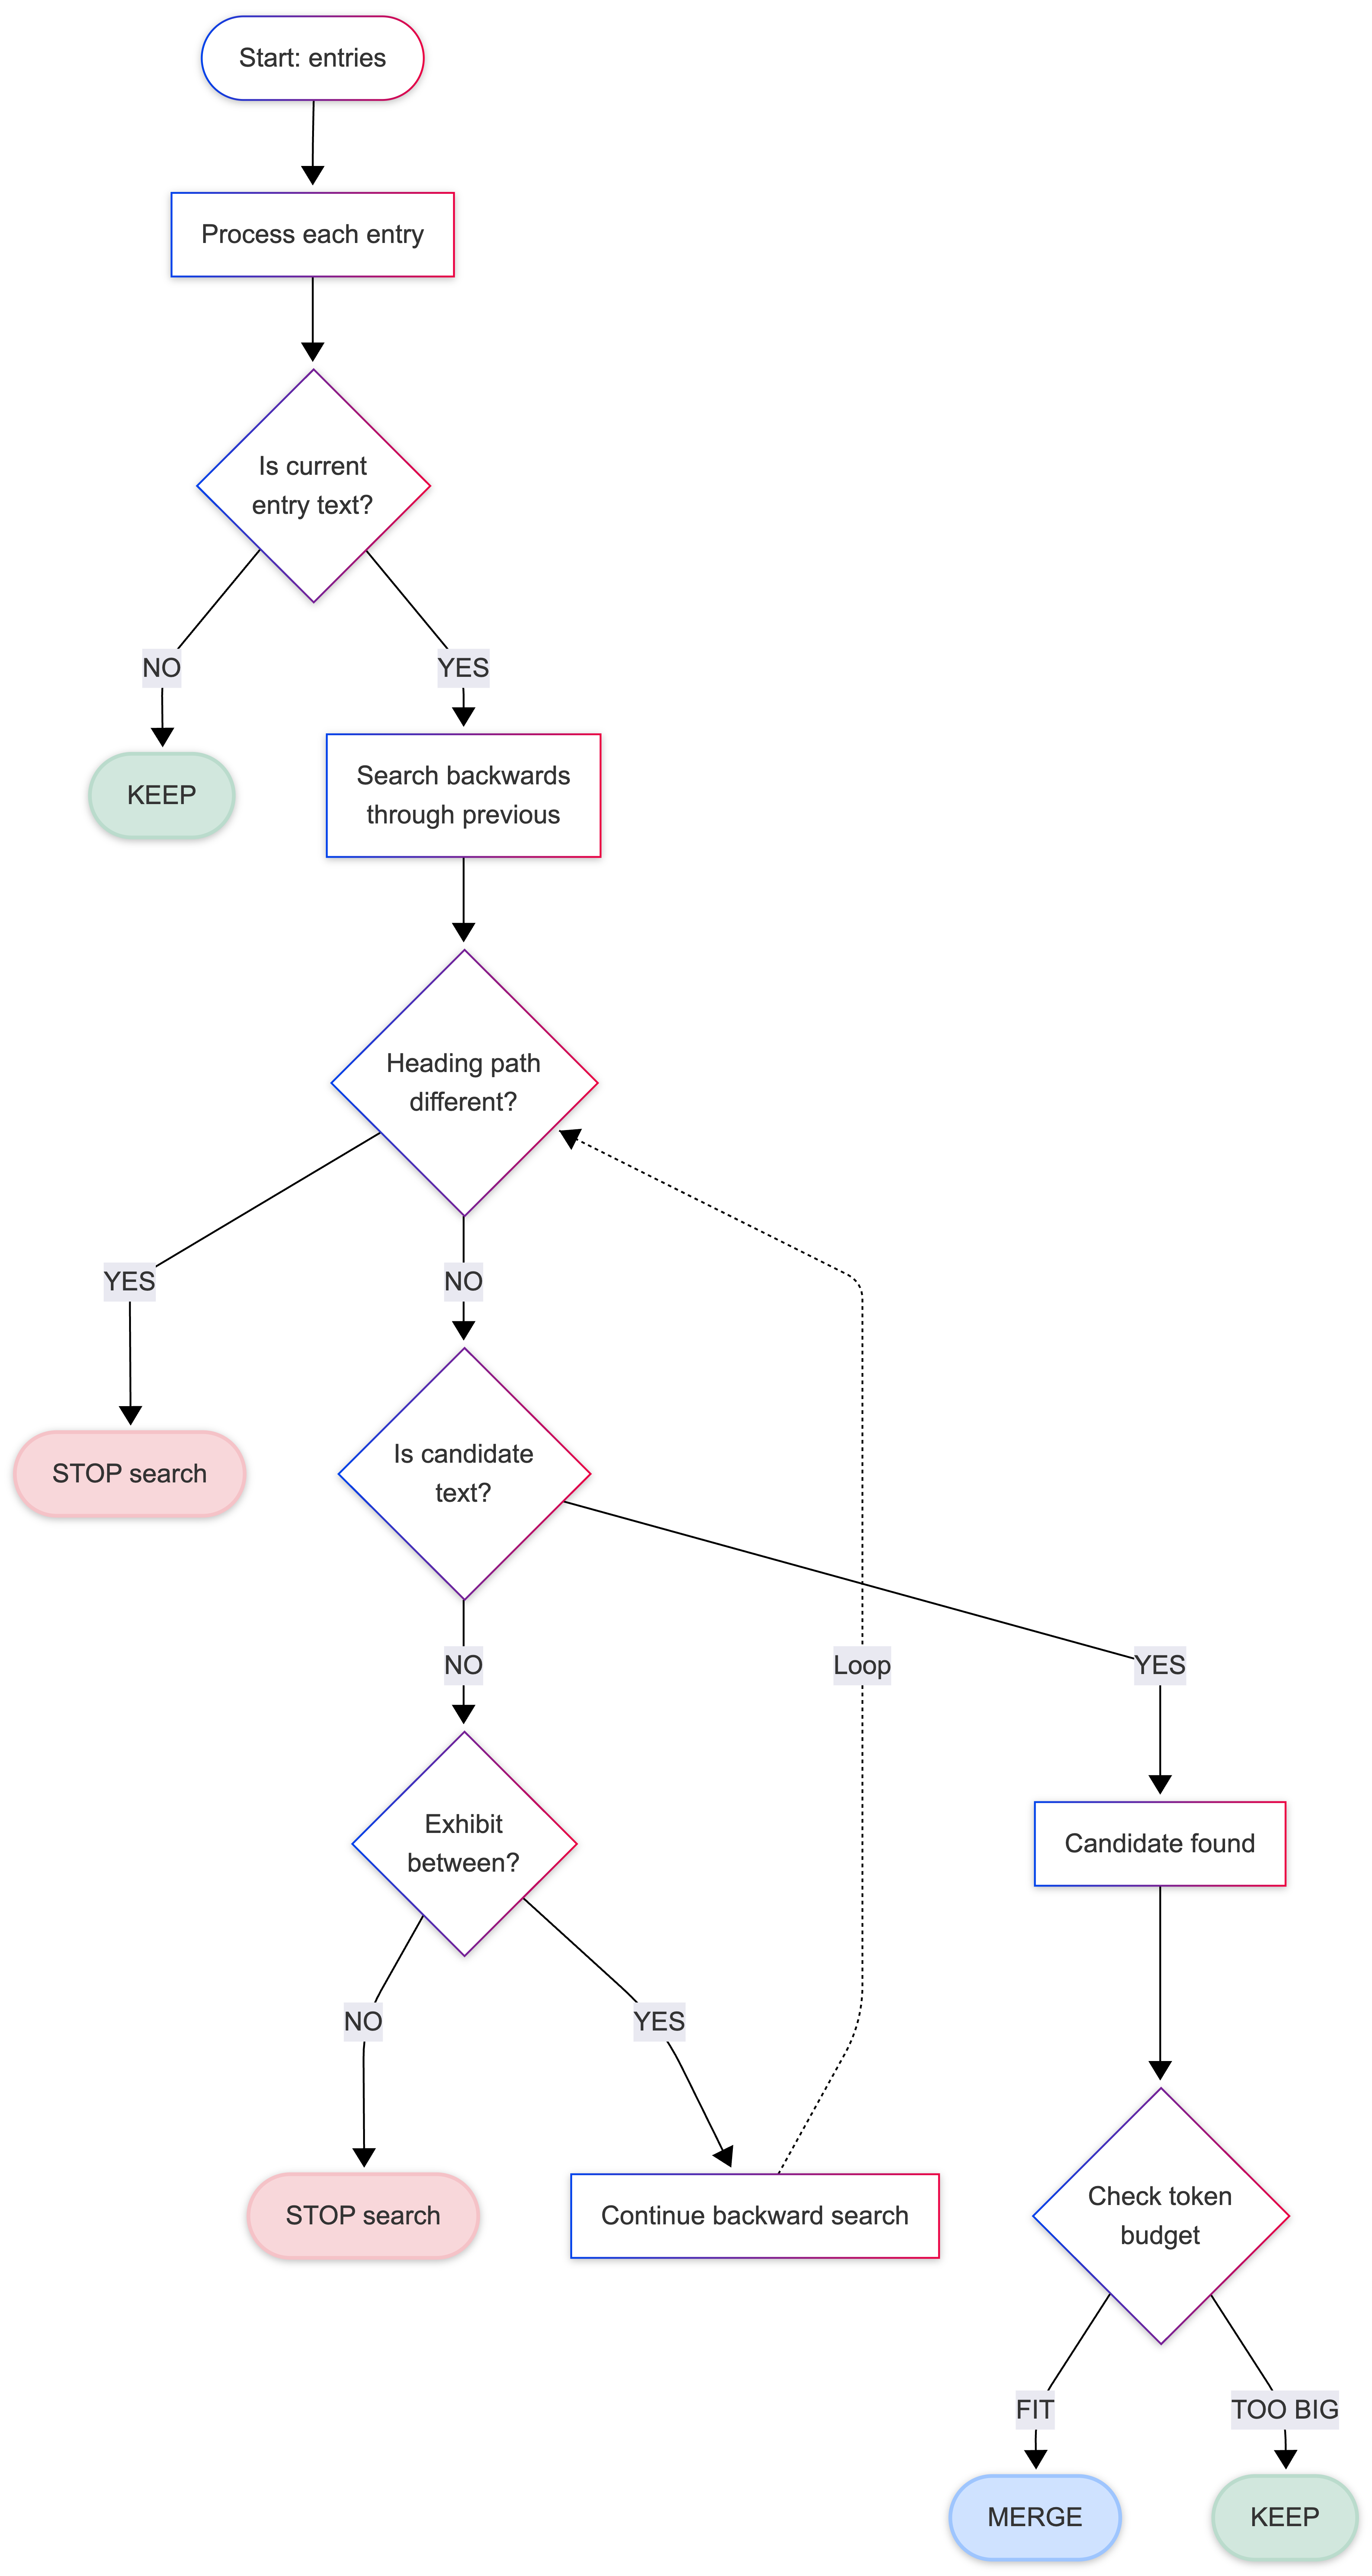

-----
| # | Rule | Condition | Result |
| --- | --- | --- | --- |
| 1 | Current entry must be text | `entry["kind"] == "text"` | Otherwise don’t search |
| 2 | Search backward | `reversed(out)` | Find earlier compatible prose |
| 3 | Heading must match | `candidate["head"] == entry["head"]` | Otherwise stop |
| 4 | Candidate must be text | `candidate["kind"] == "text"` | Only text + text |
| 5 | Exhibits may be crossed | `MERGE_ACROSS_EXHIBITS=True` | Can skip figure/table |
| 6 | Heading boundary cannot be crossed | Different head → break | Prevent cross-section merging |
| 7 | Combined text must fit | `tokens <= 400` | Otherwise don’t merge |
| 8 | Merge bodies | `target.body += entry.body` | Combine prose |
| 9 | Extend page range | `max(page_end)` | Preserve full page span |
| 10 | Mark merged | `merged=True` | Signals reconstruction later |
| 11 | Preserve image URI | target or entry | Keep associated URI |
| 12 | Count merge | `merges += 1` | Diagnostic statistic |

In [14]:
# Import the prose-merging pass.
from rag.chunking import _merge_prose

# Merge compatible adjacent prose entries under the same heading.
# The merge is type-aware and avoids welding tables/figures into prose records.
entries, merges = _merge_prose(entries)


# _apply_floor() workflow
- The purpose of _apply_floor() is to prevent very small text records from remaining as isolated chunks.

- Unlike _merge_prose(), which merges prose only when the heading path is the same, _apply_floor() can cross a heading boundary when a text record is smaller than the configured minimum token size.
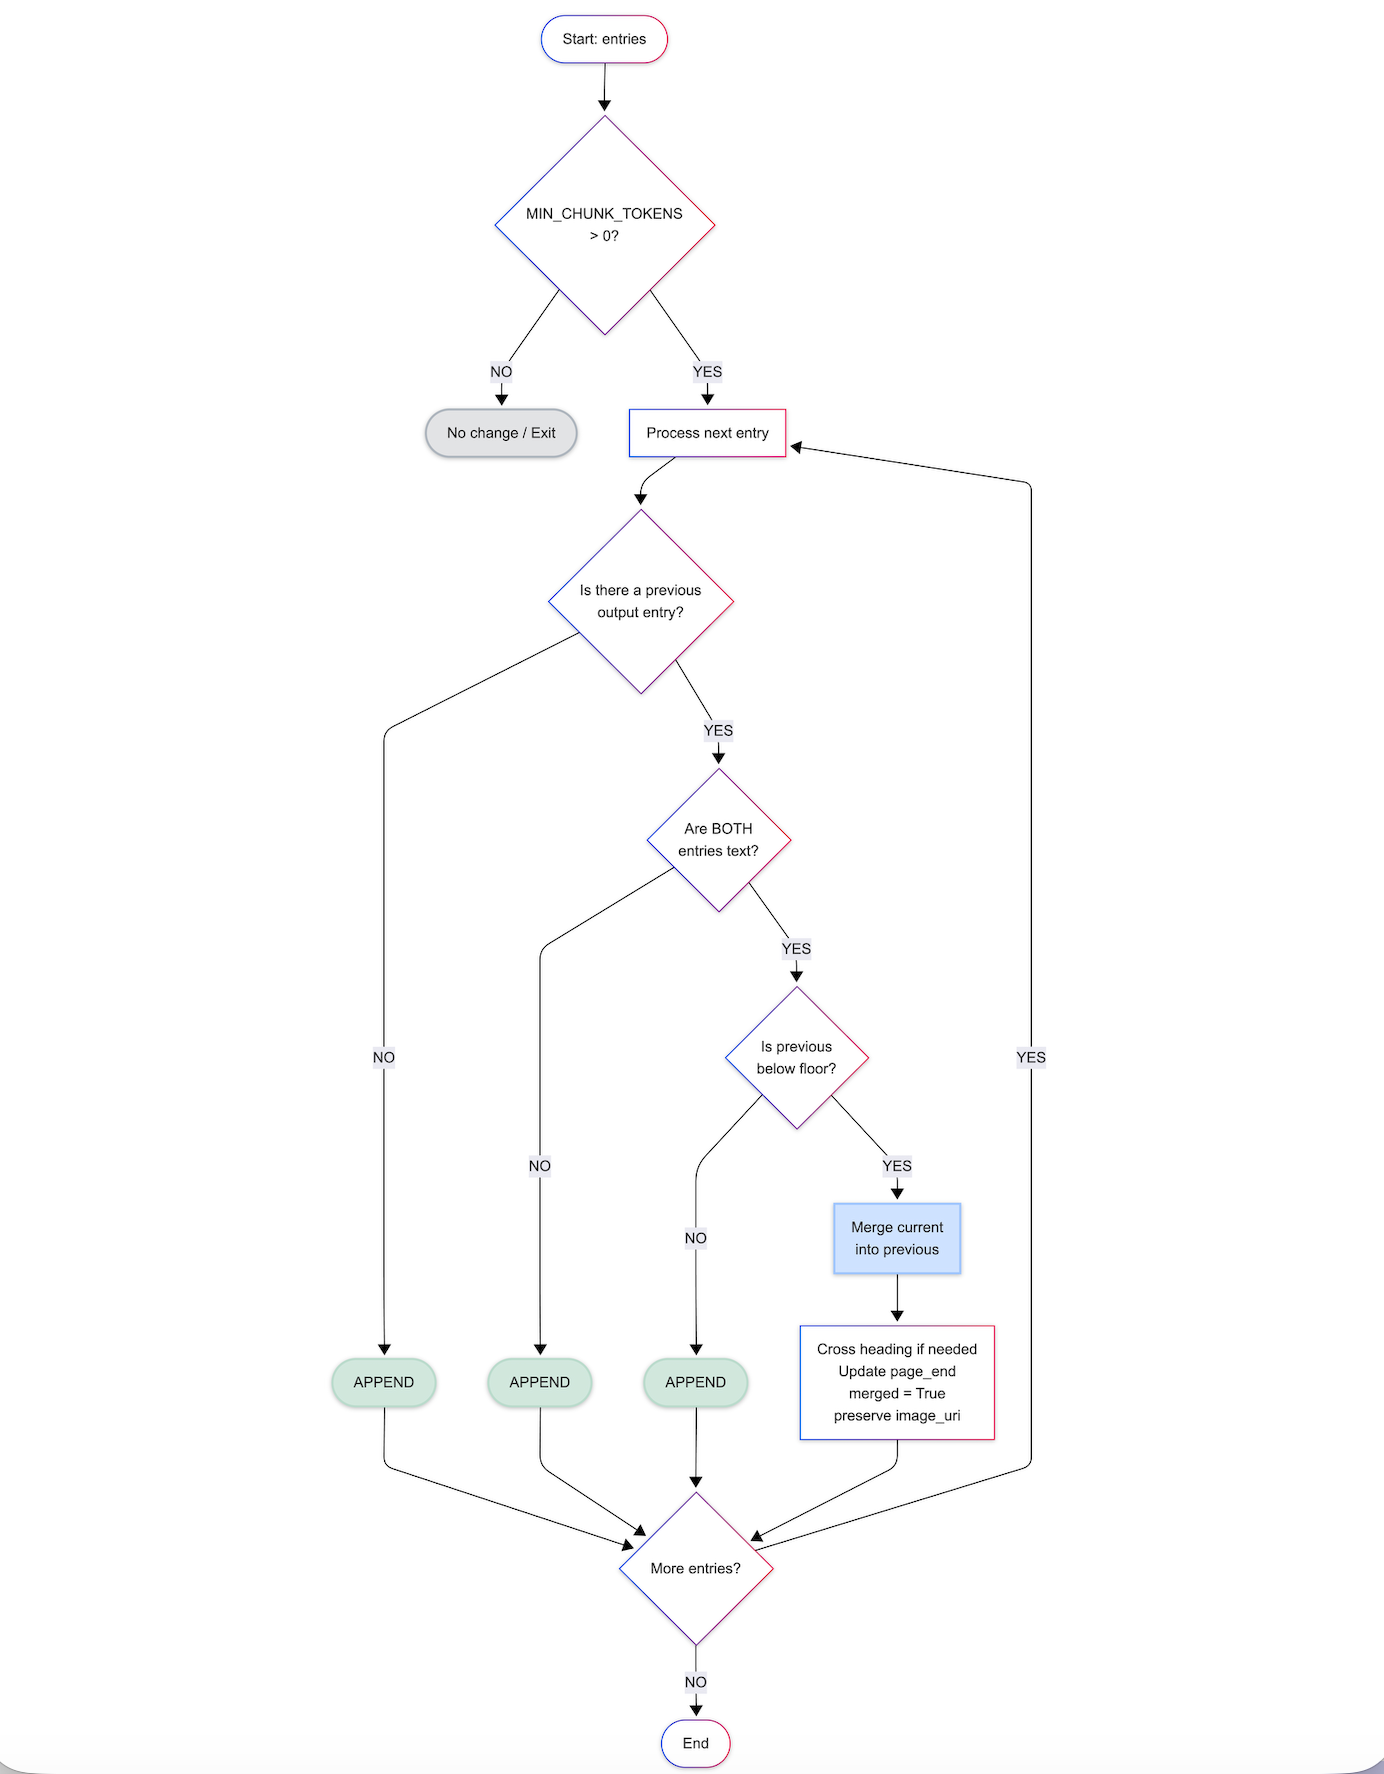

------

| # | Rule | Condition | Result |
| --- | --- | --- | --- |
| 1 | Floor disabled | `MIN_CHUNK_TOKENS <= 0` | Return unchanged |
| 2 | Process in order | `for entry in entries` | Reading-order processing |
| 3 | Previous entry required | `previous = out[-1]` | No previous → append |
| 4 | Previous must be text | `previous["kind"] == "text"` | Otherwise append |
| 5 | Current must be text | `entry["kind"] == "text"` | Otherwise append |
| 6 | Previous must be below floor | `tokens(previous) < MIN_CHUNK_TOKENS` | Otherwise append |
| 7 | Heading equality NOT required | No head comparison | Can cross headings |
| 8 | Heading crossing is explicit | Different head | Add new heading to body |
| 9 | Non-text content is a barrier | Table/figure/code/etc. | No merge |
| 10 | Page range expands | `max(page_end)` | Preserve full span |
| 11 | Mark merged | `merged=True` | Signals reconstruction |
| 12 | Preserve image URI | previous or entry | Retain URI |
| 13 | Count merge | `merges += 1` | Diagnostic |

| Feature / Behavior | `_merge_prose()` | `_apply_floor()` |
| --- | --- | --- |
| **Purpose** | Consolidate prose | Prevent tiny records |
| **Same heading required?** | ✅ Yes | ❌ No |
| **Can cross heading?** | ❌ No | ✅ Yes |
| **Can cross figure/table?** | ✅ Configurable | ❌ No |
| **Checks combined size?** | ✅ ≤ 400 tokens | ❌ No |
| **Checks previous size?** | ❌ No | ✅ < MIN_CHUNK_TOKENS |
| **Default enabled?** | ✅ Yes | ❌ No (0) |
| **Searches backward?** | ✅ Yes | ❌ Only immediate previous output |
| **Main concern** | Fragmentation | Tiny chunks |


### _apply_floor() takes a text record that is smaller than MIN_CHUNK_TOKENS and, if the next entry is also text, absorbs that next entry—even across a heading boundary—while preserving the first entry’s metadata and explicitly adding the crossed heading into the embedded body.

In [15]:
# Import the optional minimum-size floor pass.
from rag.chunking import _apply_floor

# If MIN_CHUNK_TOKENS is configured above zero, small text records can absorb the next text record.
# This is the only chunk-shaping pass that is allowed to cross a heading boundary.
entries, floor_merges = _apply_floor(entries)


# _to_records workflow
- The purpose of _to_records() is to convert the cleaned entries into the final record structure that will eventually be embedded and indexed.

- It has one special behavior:
    Normal entries become one record each, while figure_slot entries are expanded into one record per figure. Table entries are also grouped so _table_summaries() can later create one additional summary record per logical table.
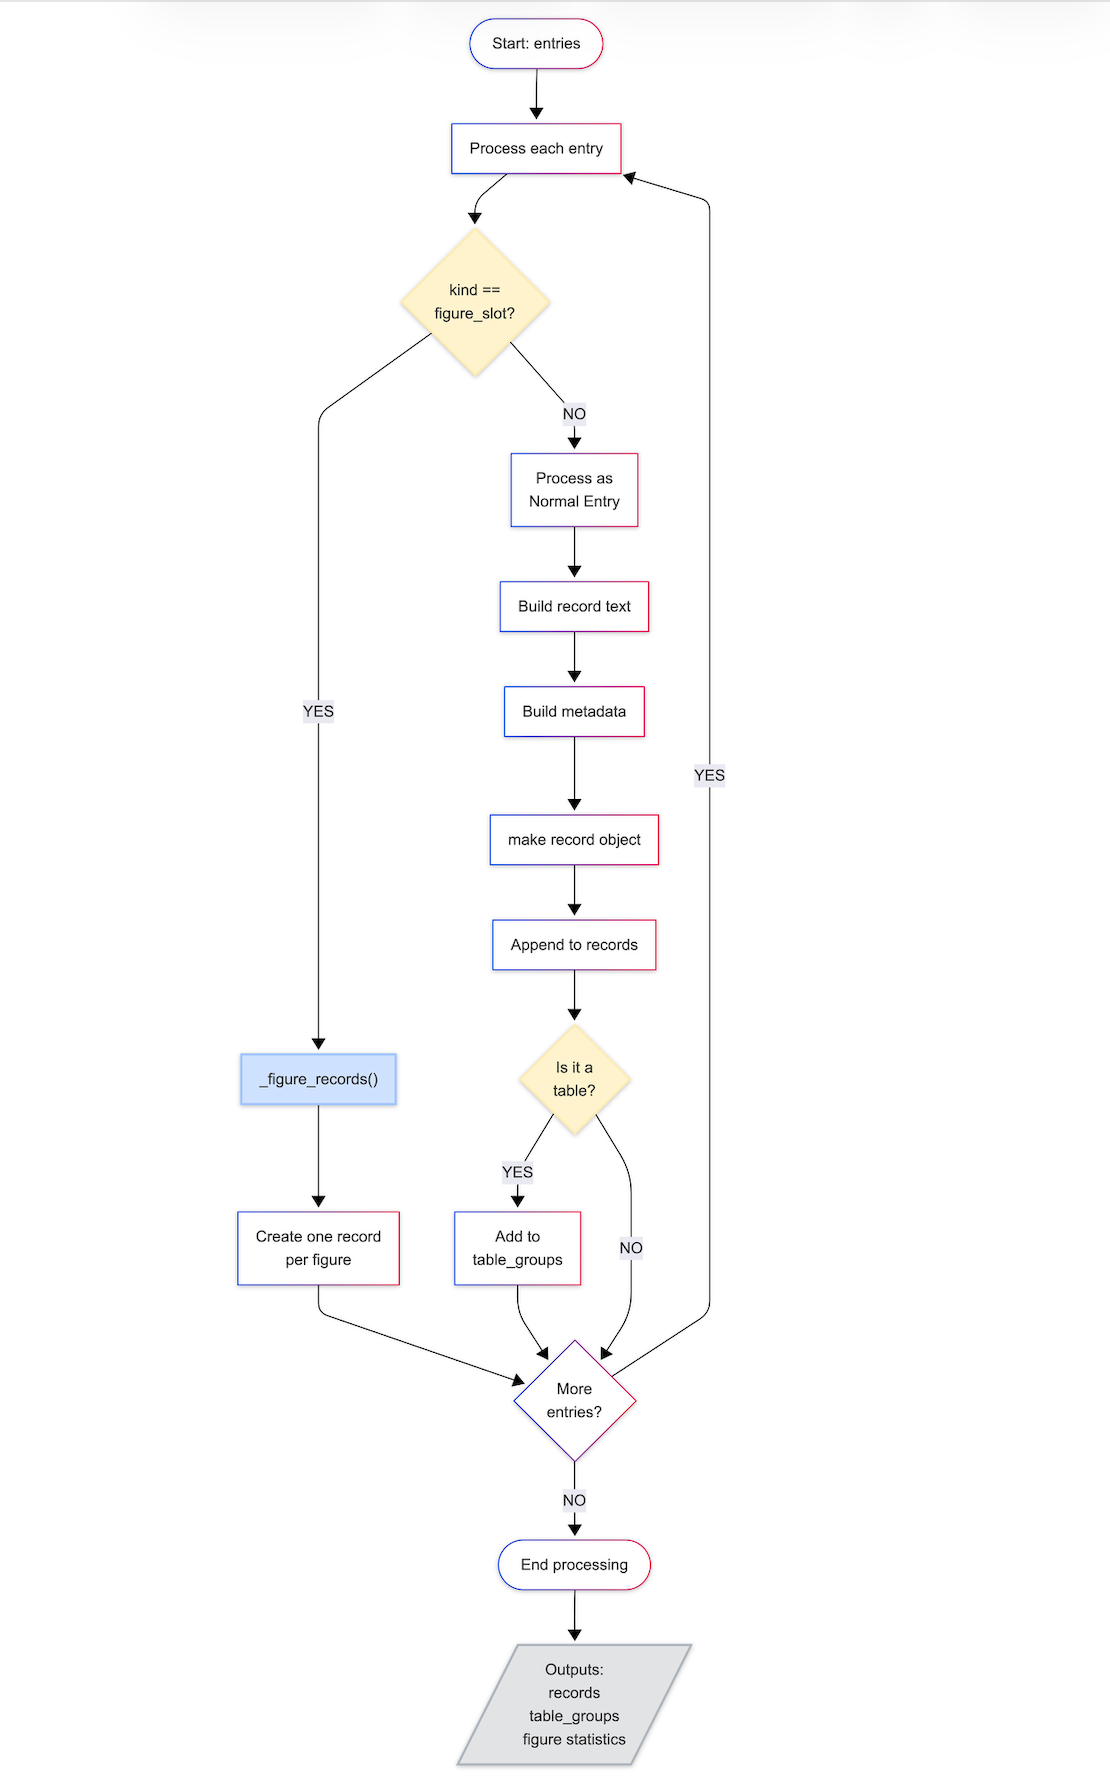
------

# Decision Tree
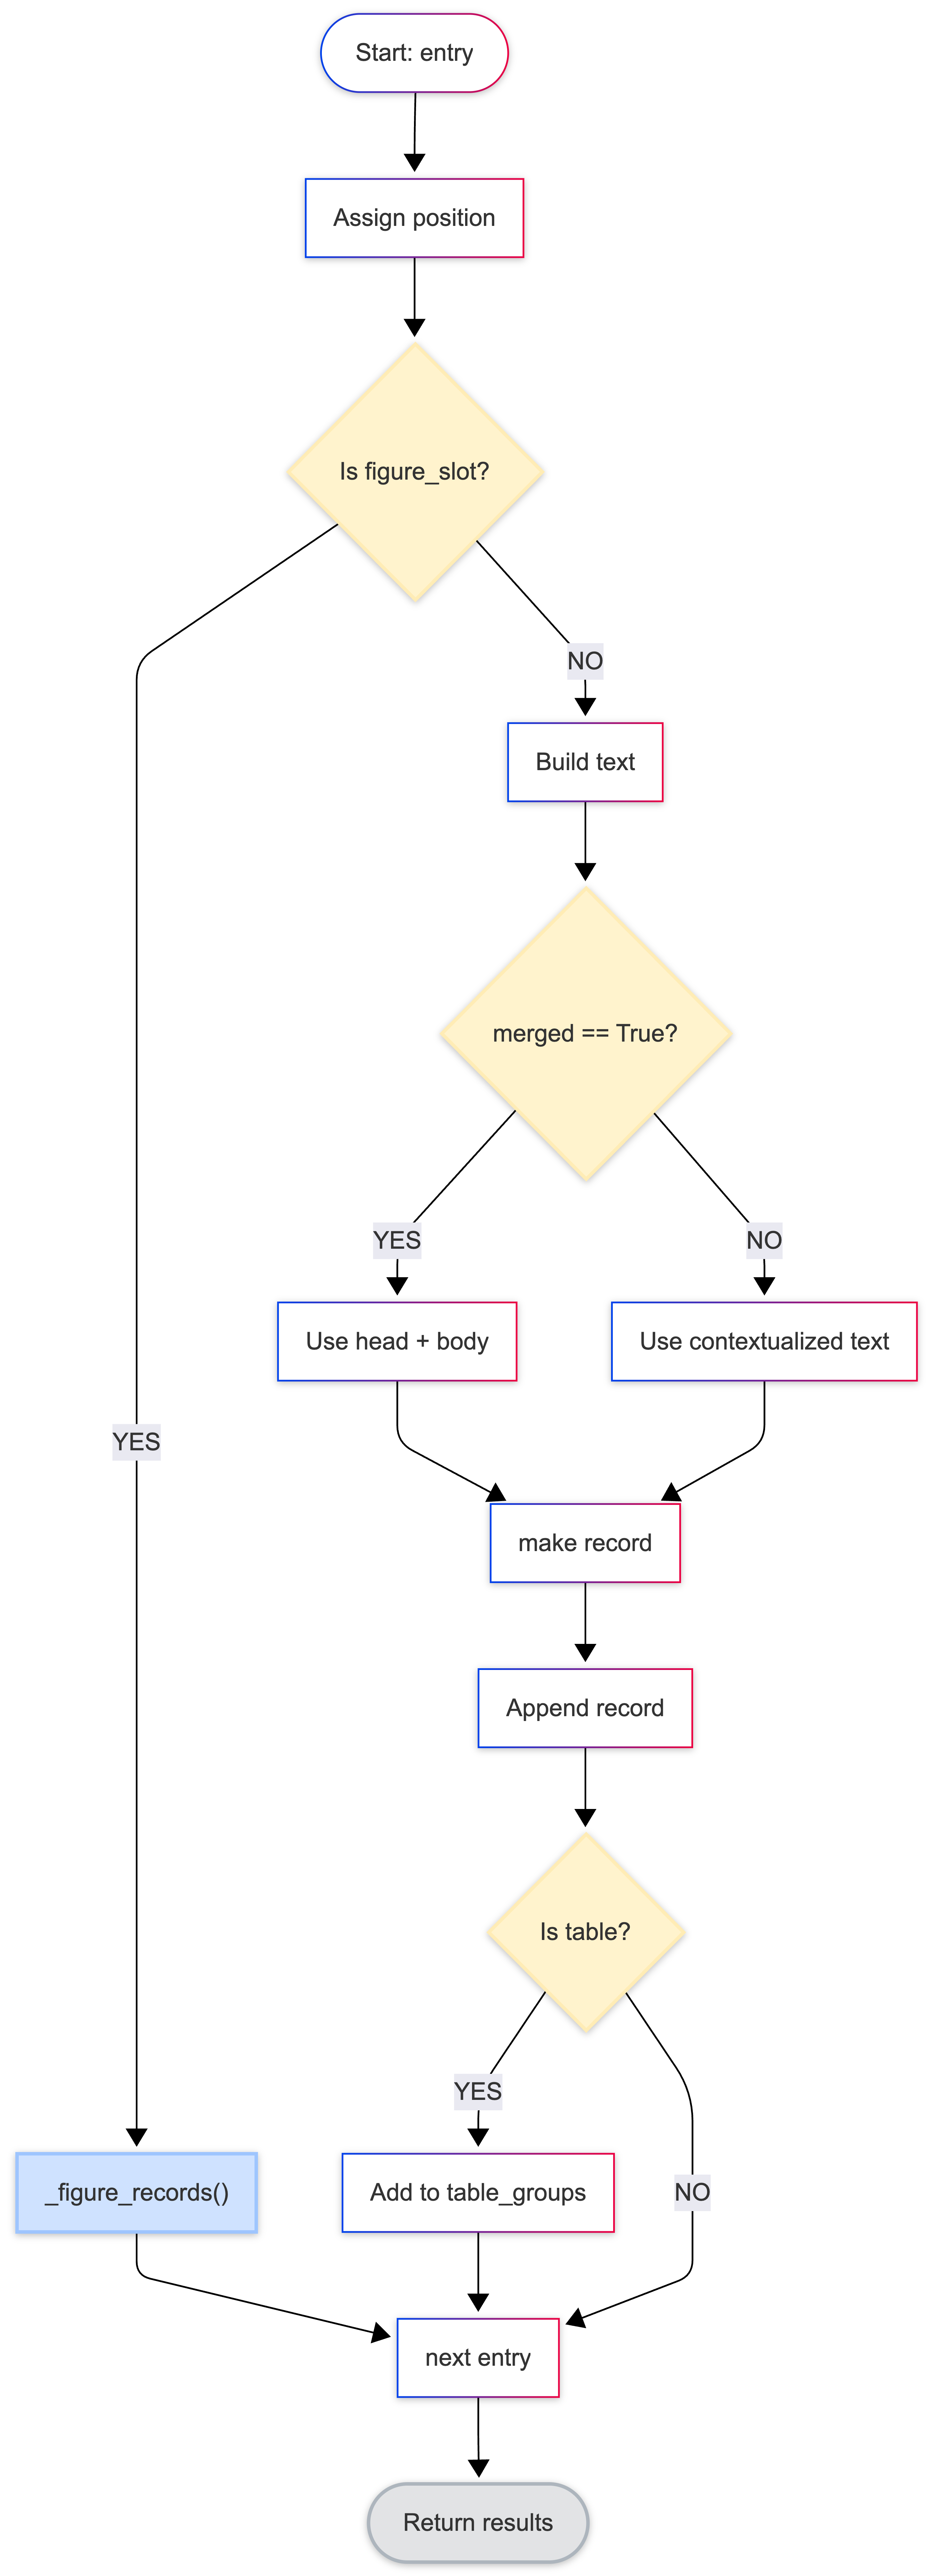

----
| # | Rule | Condition | Result |
| --- | --- | --- | --- |
| 1 | Process every entry | `for position, entry` | Assign position |
| 2 | Figure slot is special | `kind == "figure_slot"` | Expand figures |
| 3 | One figure → one record | Each figure ref | Separate figure record |
| 4 | Figure must resolve | `items_by_ref.get(ref)` | Missing item is skipped |
| 5 | Figure needs description | `picture_description(item)` | No description → skip |
| 6 | Caption is included | `caption_text(doc)` | Add to figure text |
| 7 | Chart data is included | `chart_data(item)` exists | Add to figure text |
| 8 | Merged entry | `merged == True` | Rebuild heading + body |
| 9 | Unmerged entry | `merged == False` | Use contextualized |
| 10 | Every normal entry → one record | Not `figure_slot` | Call `make()` |
| 11 | Store page range | `page`, `page_end` | Preserve source location |
| 12 | Store headings | `entry["head"]` | Retrieval/filter metadata |
| 13 | Create section ID | `_section_id(head)` | Stable section grouping |
| 14 | Classify content | `entry["kind"]` | text/table/formula/code/etc. |
| 15 | Create table ID | `ref` exists | Hash table reference |
| 16 | Group table fragments | `if ref` | Add to `table_groups` |
| 17 | Preserve image URI | `entry["image_uri"]` | Attach image reference |
| 18 | Count indexed figures | Successful figure record | `indexed += 1` |
| 19 | Count skipped figures | Missing description | `skipped += 1` |
| 20 | Detect mixed figures | Picture not in slot | `figures_merged` |

# Record Format
-  text is the searchable/embeddable content, while metadata tells the system where it came from, what it represents, how it relates to other records, and how it should be retrieved/displayed.
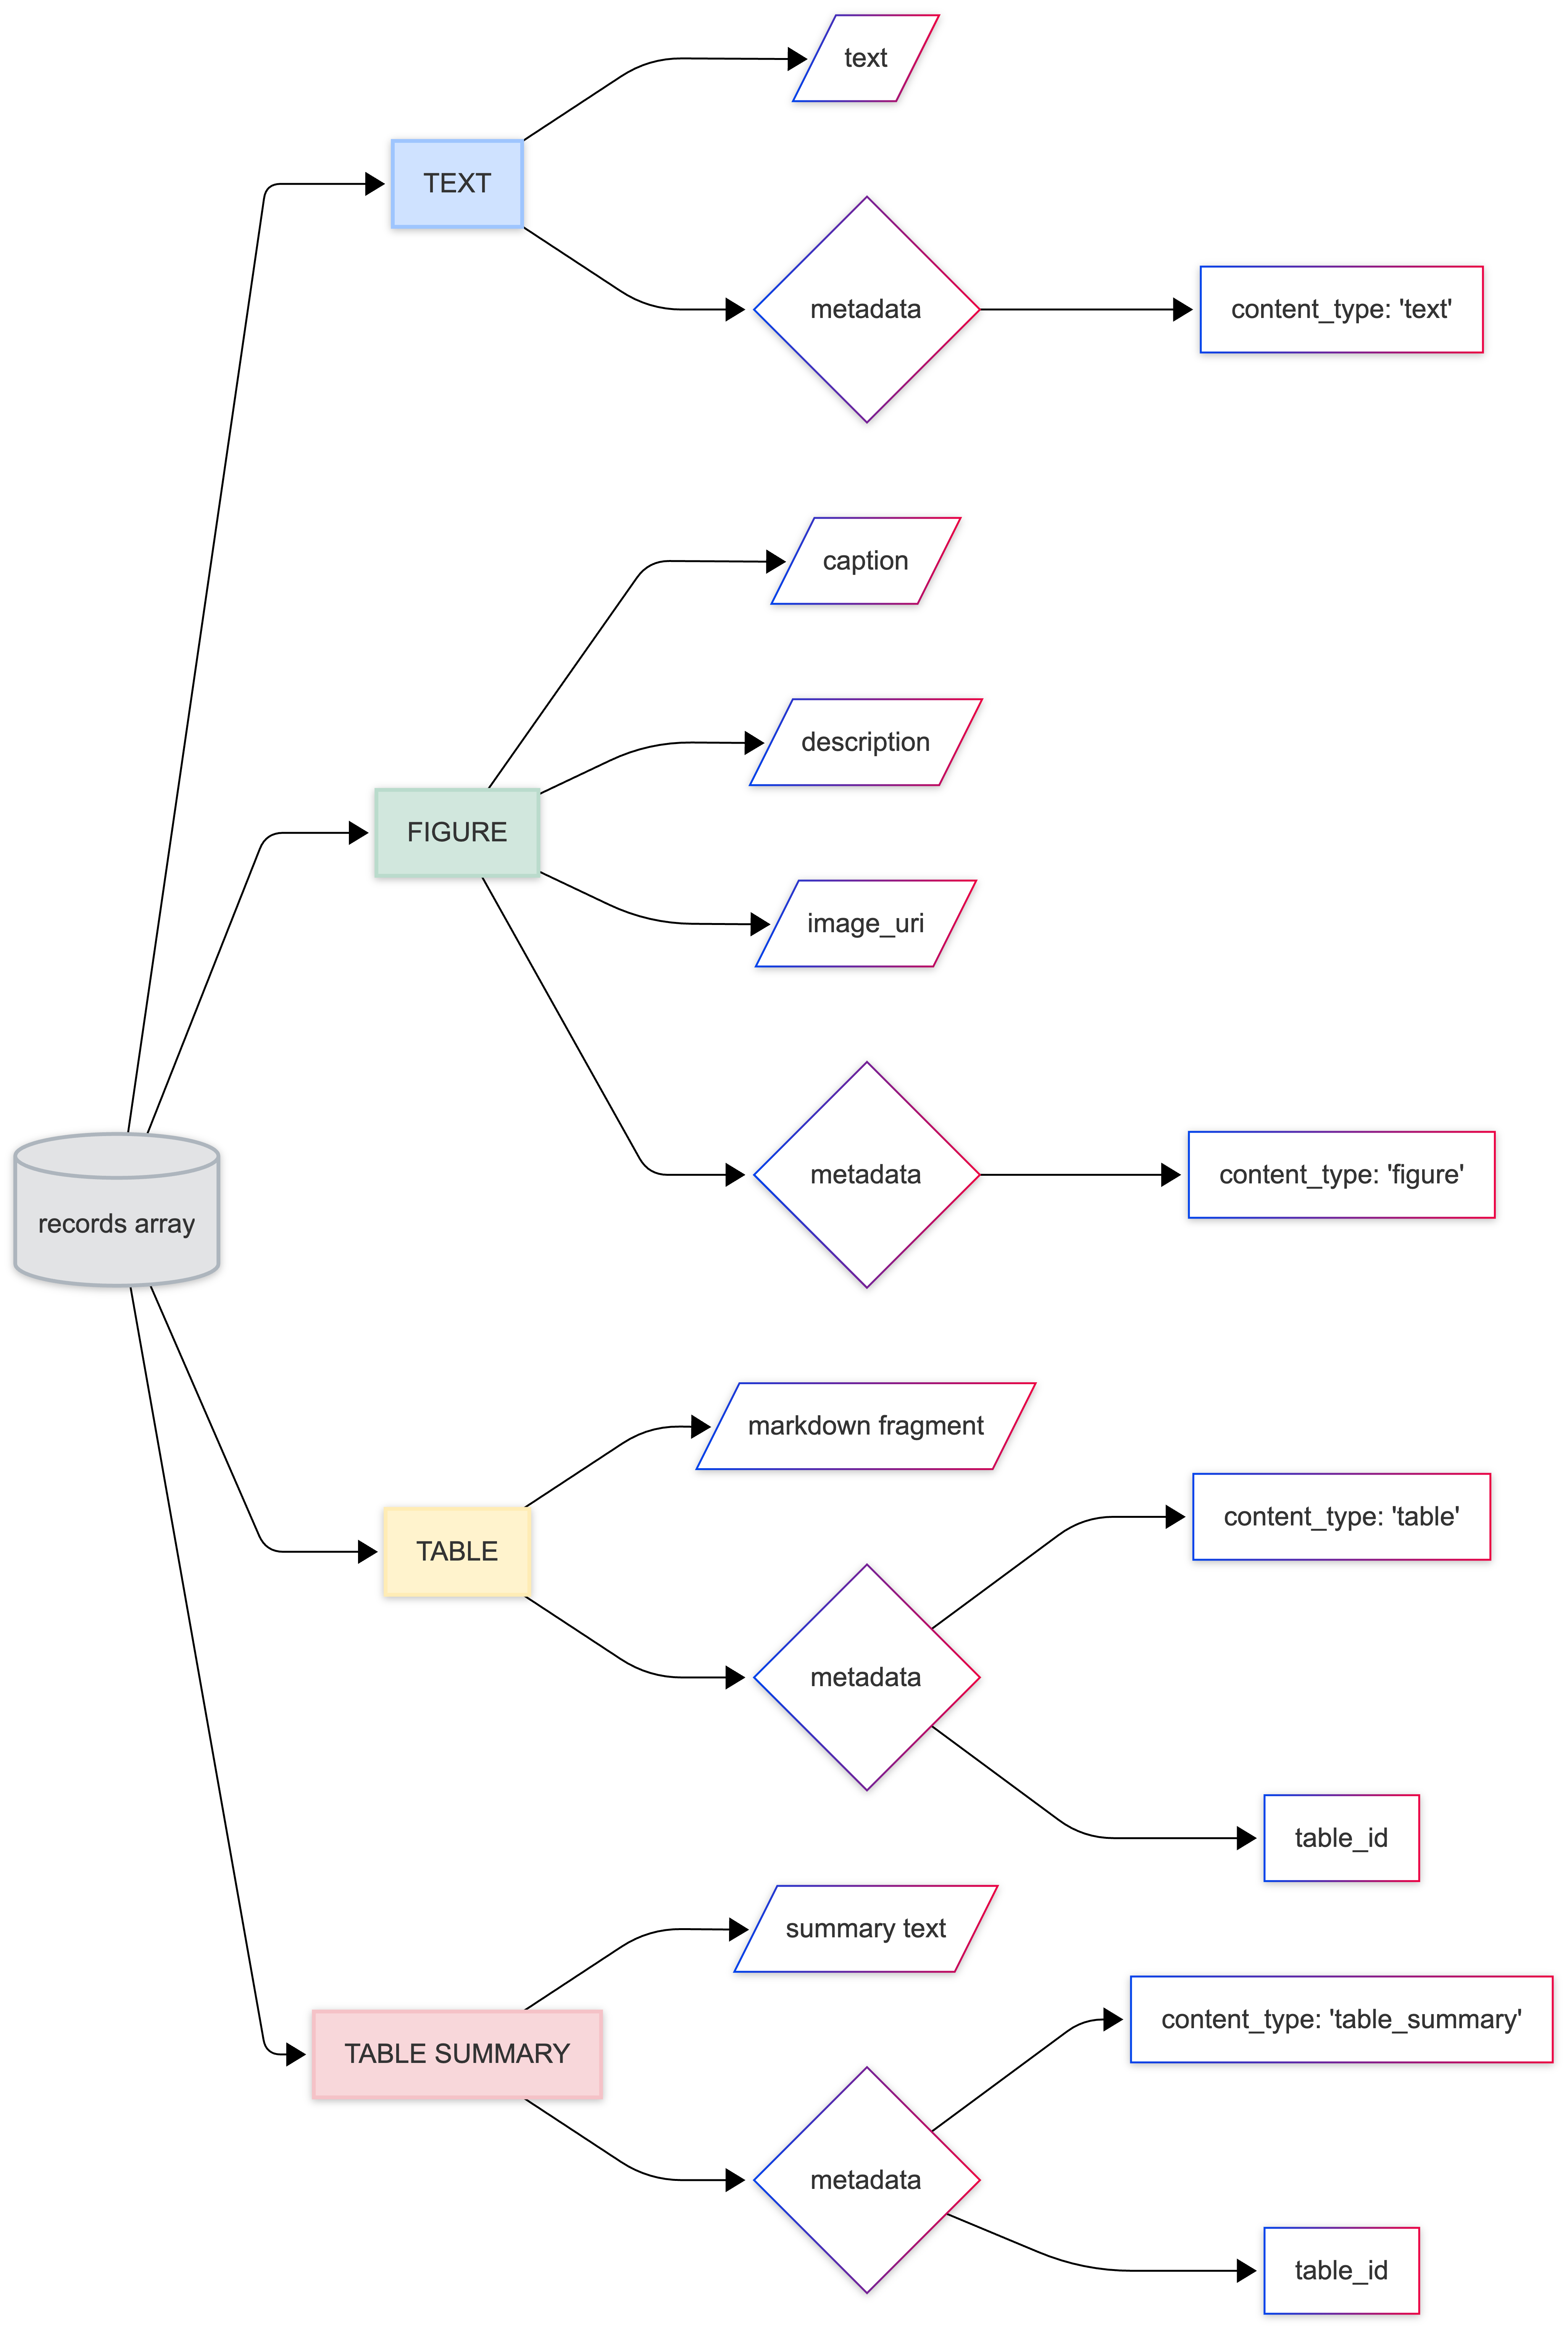

--------

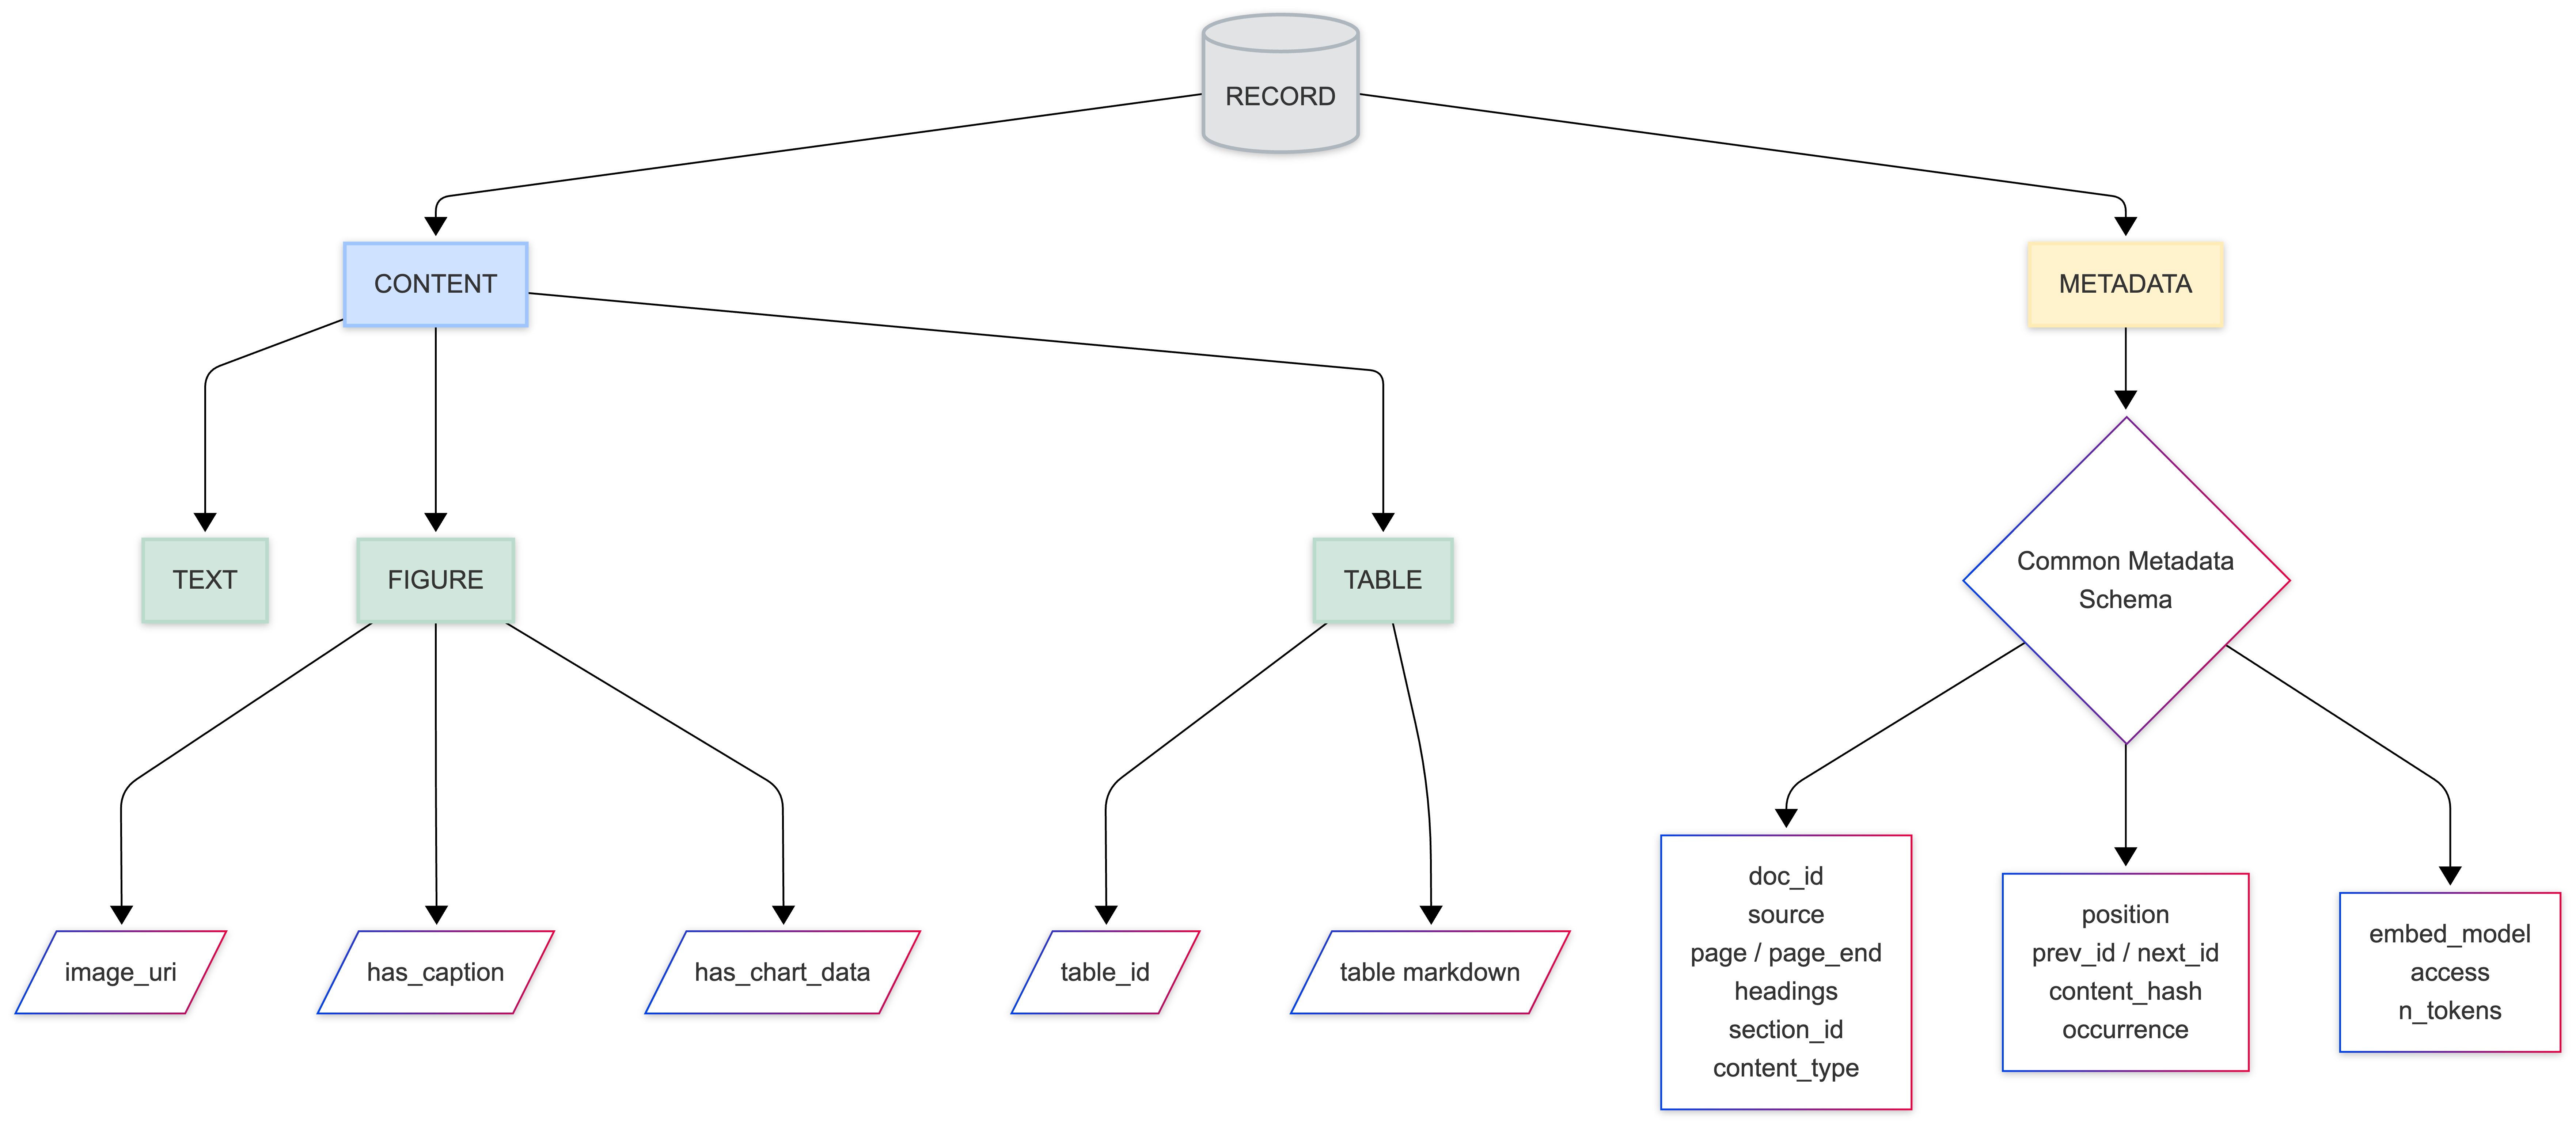

| Record Type | What Goes Into `text` | Example |
|---|---|---|
| **Text record** | Heading path + prose | AI Infrastructure<br>Agent Architecture<br>AI agents use tools to interact with external systems. |
| **Figure record** | Heading path + caption + description + chart data (if available) | AI Infrastructure<br>Agent Architecture<br>Figure 3: Agent Architecture<br>The diagram shows the interaction between the agent, tools, and memory.<br>Chart data: ... |
| **Table record** | Heading path + table content (Markdown) | AI Infrastructure<br>Vendor Comparison<br>`| Vendor | Model | Context |`<br>`|---|---|---|`<br>`| A | X | 128K |` |
| **Table summary** | Heading path + semantic summary of the table | AI Infrastructure<br>Vendor Comparison<br>This table compares AI vendors based on model capabilities and context window size. |

-------
| Field | Text | Figure | Table | Table Summary |
|---|---|---|---|---|
| **id** | ✓ | ✓ | ✓ | ✓ |
| **text** | Prose | Caption + description | Table markdown | Table summary |
| **doc_id** | ✓ | ✓ | ✓ | ✓ |
| **source** | ✓ | ✓ | ✓ | ✓ |
| **doc_date** | ✓ | ✓ | ✓ | ✓ |
| **ingested_at** | ✓ | ✓ | ✓ | ✓ |
| **position** | ✓ | ✓ | ✓ | ✓ |
| **prev_id** | ✓ | ✓ | ✓ | ✓ |
| **next_id** | ✓ | ✓ | ✓ | ✓ |
| **content_hash** | ✓ | ✓ | ✓ | ✓ |
| **occurrence** | ✓ | ✓ | ✓ | ✓ |
| **embed_model** | ✓ | ✓ | ✓ | ✓ |
| **access** | ✓ | ✓ | ✓ | ✓ |
| **n_tokens** | ✓ | ✓ | ✓ | ✓ |
| **page** | ✓ | ✓ | ✓ | ✓ |
| **page_end** | ✓ | ✓ | ✓ | ✓ |
| **headings** | ✓ | ✓ | ✓ | ✓ |
| **section_id** | ✓ | ✓ | ✓ | ✓ |
| **content_type** | "text" | "figure" | "table" | "table_summary" |
| **table_id** | Empty | Empty | ✓ | ✓ |
| **image_uri** | Empty | ✓ | Usually empty | Empty |
| **has_caption** | — | ✓ | — | — |
| **has_chart_data** | — | ✓ | — | — |



In [16]:
# Import the conversion function and record-ID factory.
from rag.chunking import _to_records, _record_factory

# Build a lookup from every Docling element reference to its original document item.
# This is needed later to resolve figure and table references back to their source elements.
items_by_ref = {}

# Walk through all document elements in document order.
for item, _ in doc.iterate_items():
    # Read the stable Docling self-reference for this element.
    ref = getattr(item, "self_ref", None)

    # Only store elements that actually have a reference.
    if ref:
        items_by_ref[ref] = item

# Create the record factory for this document.
# The factory owns the occurrence counter used to keep identical repeated text as separate records.
make = _record_factory(SOURCE_PDF, DOC_ID, doc_date)

# Convert entries into embedding-ready records.
# Figure slots expand into one record per figure, while table fragments are grouped by logical table.
records, table_groups, fig_stats = _to_records(
    entries, doc, items_by_ref, uris, make)


In [28]:
print(records[0])
print("-------------")
for record in records:
    if record['meta']['content_type'] == 'figure':
        print(record)
        break
print("-------------")
print(records[5])
print("-------------")
print(records[4])

{'text': 'M January 6, 2025 10:00 PM GMT', 'meta': {'chunk_id': 'ai-enablers-adopters-research-report:c092187aff552a3e:0', 'content_hash': 'c092187aff552a3e', 'occurrence': 0, 'doc_id': 'ai-enablers-adopters-research-report', 'source': 'AI-Enablers-Adopters-research-report.pdf', 'doc_date': '2025', 'ingested_at': 1788401969, 'position': 0, 'embed_model': 'text-embedding-3-small', 'access': ['public'], 'n_tokens': 14, 'page': 1, 'page_end': 1, 'headings': [], 'section_id': 'e3b0c44298fc', 'content_type': 'text', 'table_id': '', 'image_uri': '', 'n_positions': 34, 'next_id': 'ai-enablers-adopters-research-report:df1e8e20ec6836da:0', 'text': 'M January 6, 2025 10:00 PM GMT'}}
-------------
{'text': "Uncovering Alpha in AI's Rate of Change\nExhibit 1 : Stock returns where both materiality and exposure were increased\n**Chart Type:** Line Chart\n\n**X-Axis:** Time Period (Months from December 2023 to November 2024)\n\n**Y-Axis:** Indexed Value (Units: Indexed to 100)\n\n**Series/Categories 

# _table_summaries
- _table_summaries() creates one additional semantic summary record for each logical table. It does not replace the original table records.
- **_table_summaries() adds a semantic layer on top of the exact table chunks. It does not replace them.**

**Table fragments = exact data**

**Table summary = semantic understanding**

## Why is _table_summaries needed?
| Problem | What happens without `_table_summaries` | What `_table_summaries` provides |
| --- | --- | --- |
| **Large tables** | A table may be split into multiple chunks/fragments. | Creates one concise representation of the entire table. |
| **Semantic questions** | A query like “Which vendors are compared in this table?” may not match exact table cells well. | Summary contains the overall meaning of the table, making semantic retrieval easier. |
| **Exact-value questions** | Exact values need the original table content. | Original table fragments are preserved for exact-value retrieval. |
| **Table understanding** | Embedding individual fragments may lose the overall context of the table. | Summary captures what the table is about. |
| **Retrieval** | Retriever may return only one fragment of a large table. | Summary can identify the relevant table first. |
| **Table grouping** | Multiple fragments need to be recognized as one logical table. | Summary uses the same `table_id` as all table fragments. |

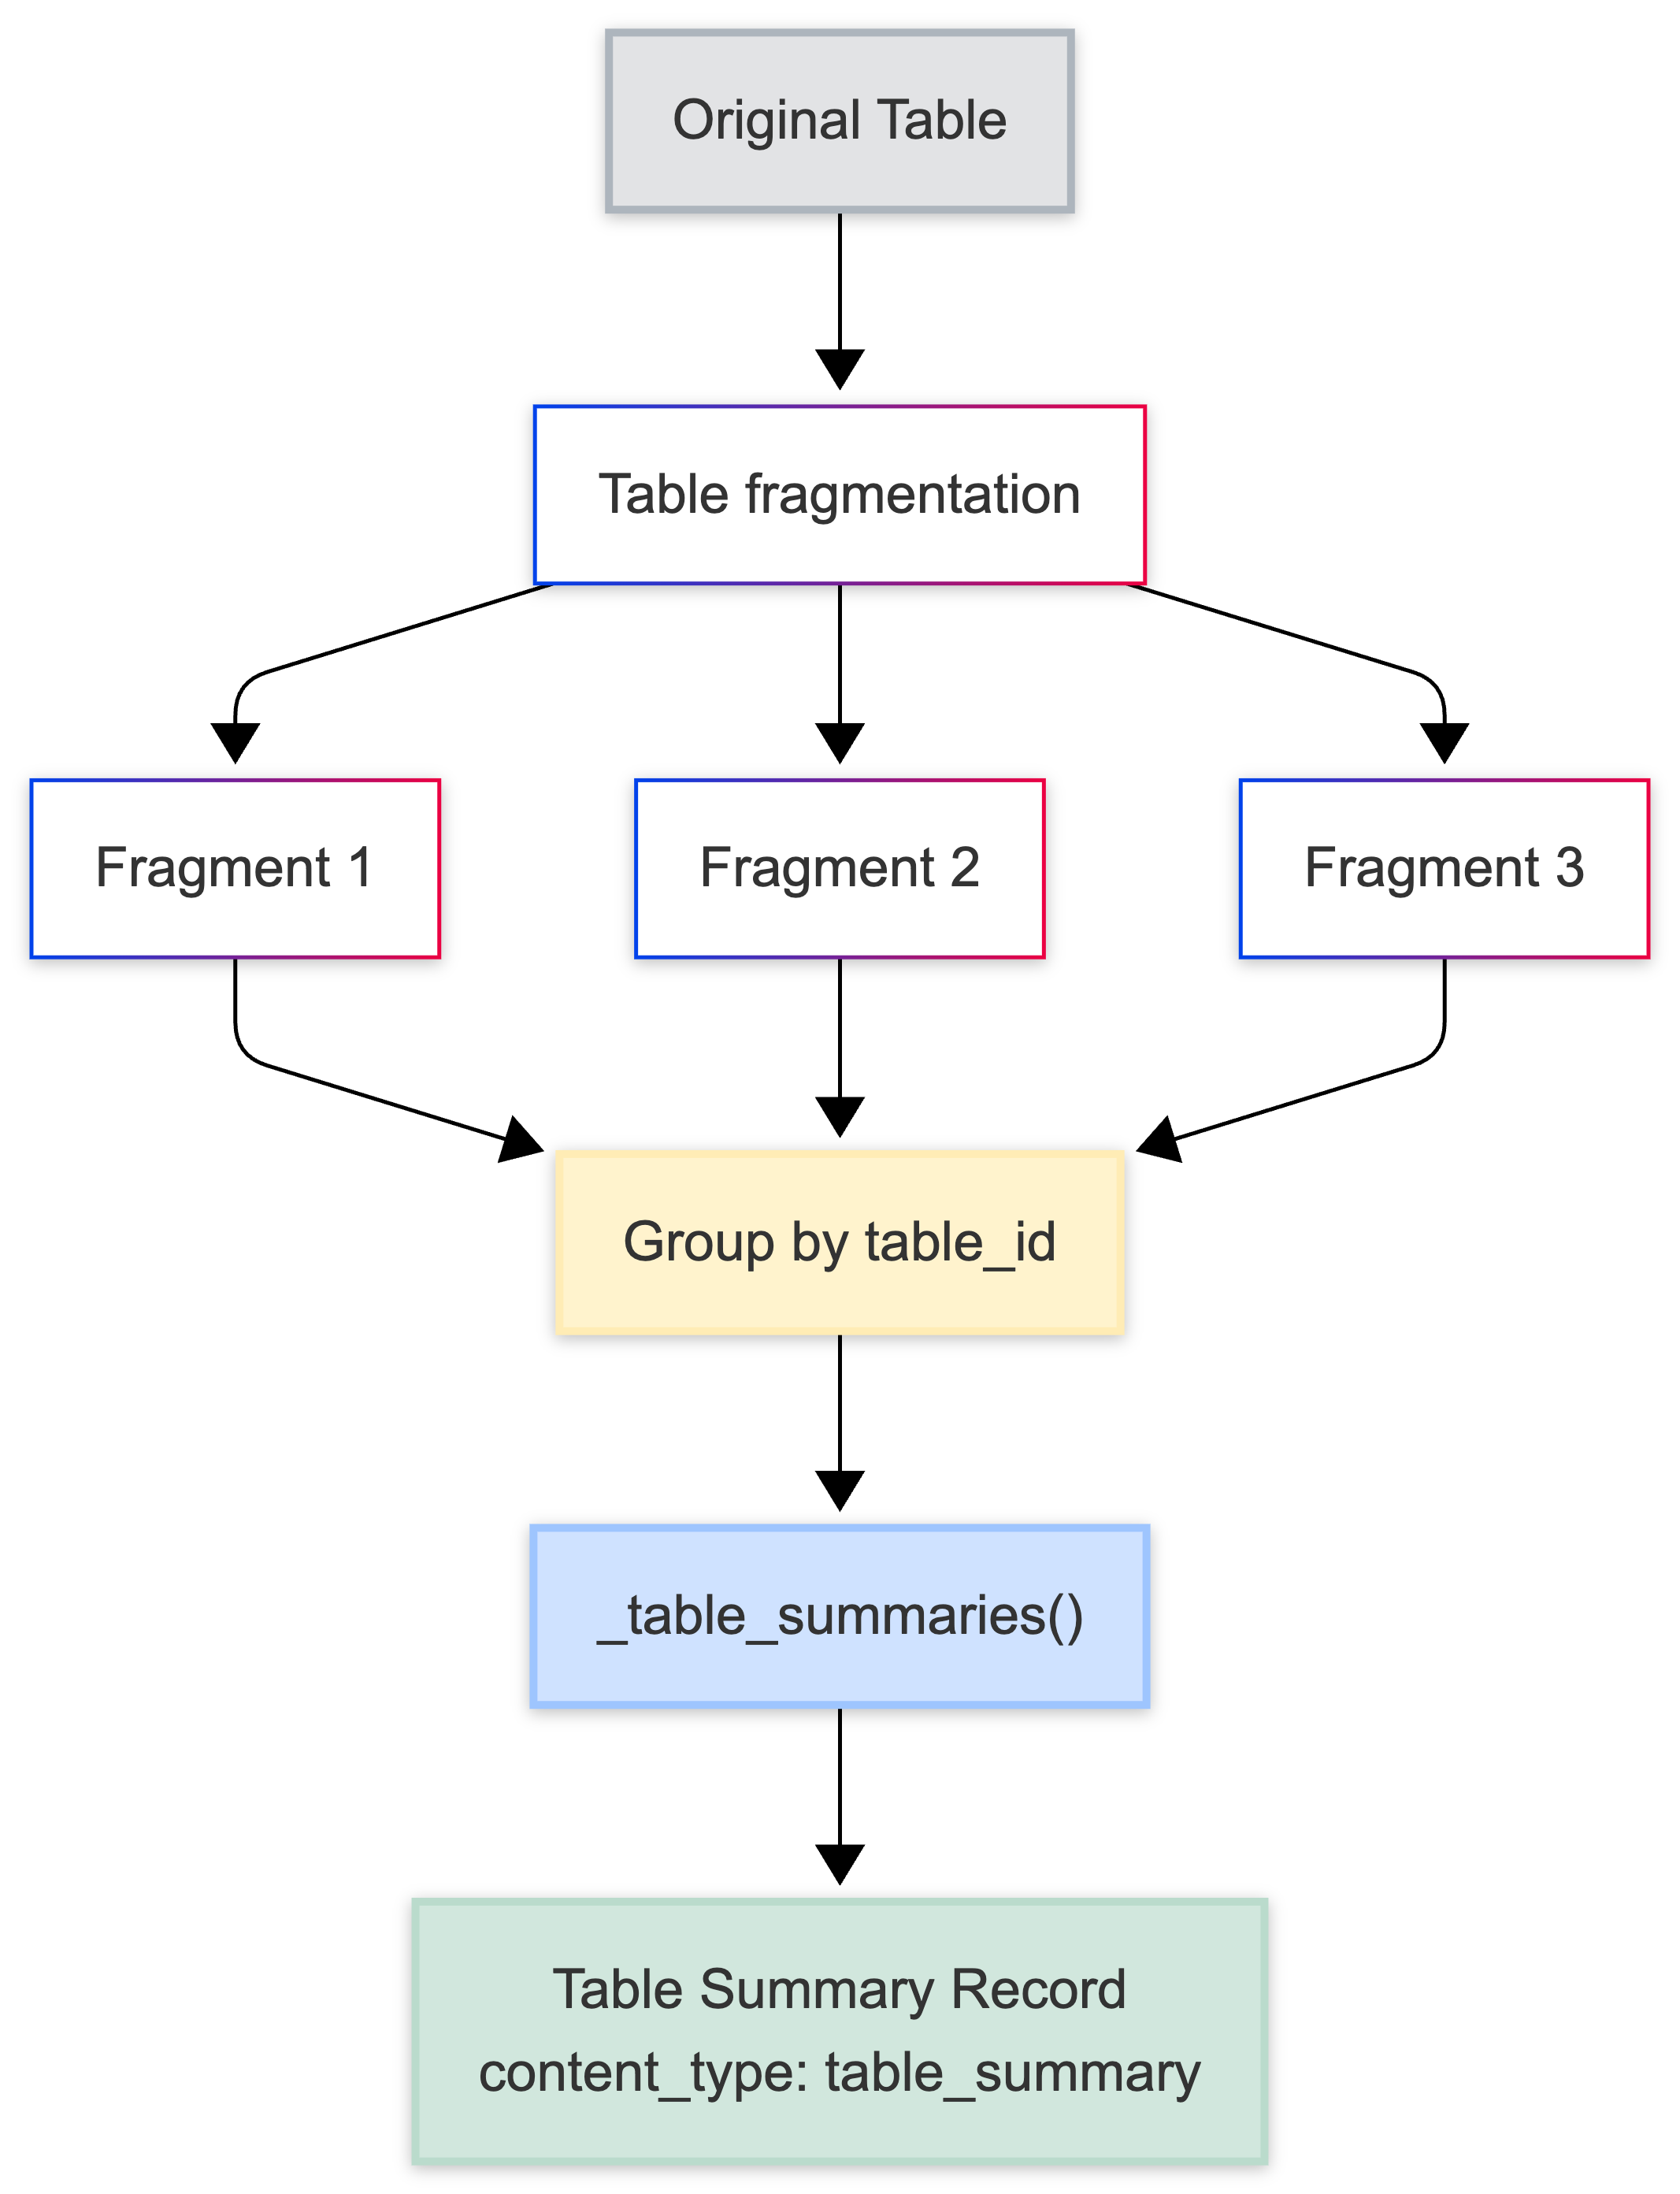




In [17]:
# Import the table serializer used to reconstruct complete logical tables from the document.
from rag.tables import table_markdown

# Import the pass that creates searchable table-summary records.
from rag.chunking import _table_summaries

# Serialize each logical table from the complete document structure.
tables = table_markdown(doc)

# Create one additional summary record for each table that needs a summary.
# The original table fragments remain in records because they contain exact values.
summaries, table_stats = _table_summaries(
    table_groups, tables, doc, items_by_ref, make)

# Append the table summaries to the existing records.
records += summaries


## _finalise — Why Do We Need It?

_finalise() is the last cleanup and validation step before the records are sent to the embedding/indexing pipeline.

It takes the records produced by _to_records() and makes sure they are in the correct final order, correctly linked, and within size/metadata limits.

What _finalise Does
| Step | What It Does | Why It Is Needed |
|---|---|---|
| **1. Sort records** | Orders records by their original document position. Table summaries are placed immediately before their table fragments. | Preserves document reading order. |
| **2. Reassign position** | Gives every record its final sequential position after sorting. | Ensures positions accurately represent the final record order. |
| **3. Build prev_id** | Sets each record’s previous-record ID. | Allows navigation to the previous chunk. |
| **4. Build next_id** | Sets each record’s next-record ID. | Allows navigation to the next chunk. |
| **5. Bound metadata** | Ensures metadata stays within the Pinecone metadata size limit. | Prevents indexing failures caused by oversized metadata. |
| **6. Check chunk size** | Detects records whose text is still larger than the allowed token limit. | Protects the embedding/indexing stage from oversized chunks. |
| **7. Truncate oversized records** | Truncates unsplittable text to `CHUNK_TOKENS` and marks it as truncated. | Ensures the final record can be embedded safely. |
| **8. Mark truncated** | Records whether truncation occurred (`truncated = True`). | Makes the data-loss event visible for debugging/auditing. |

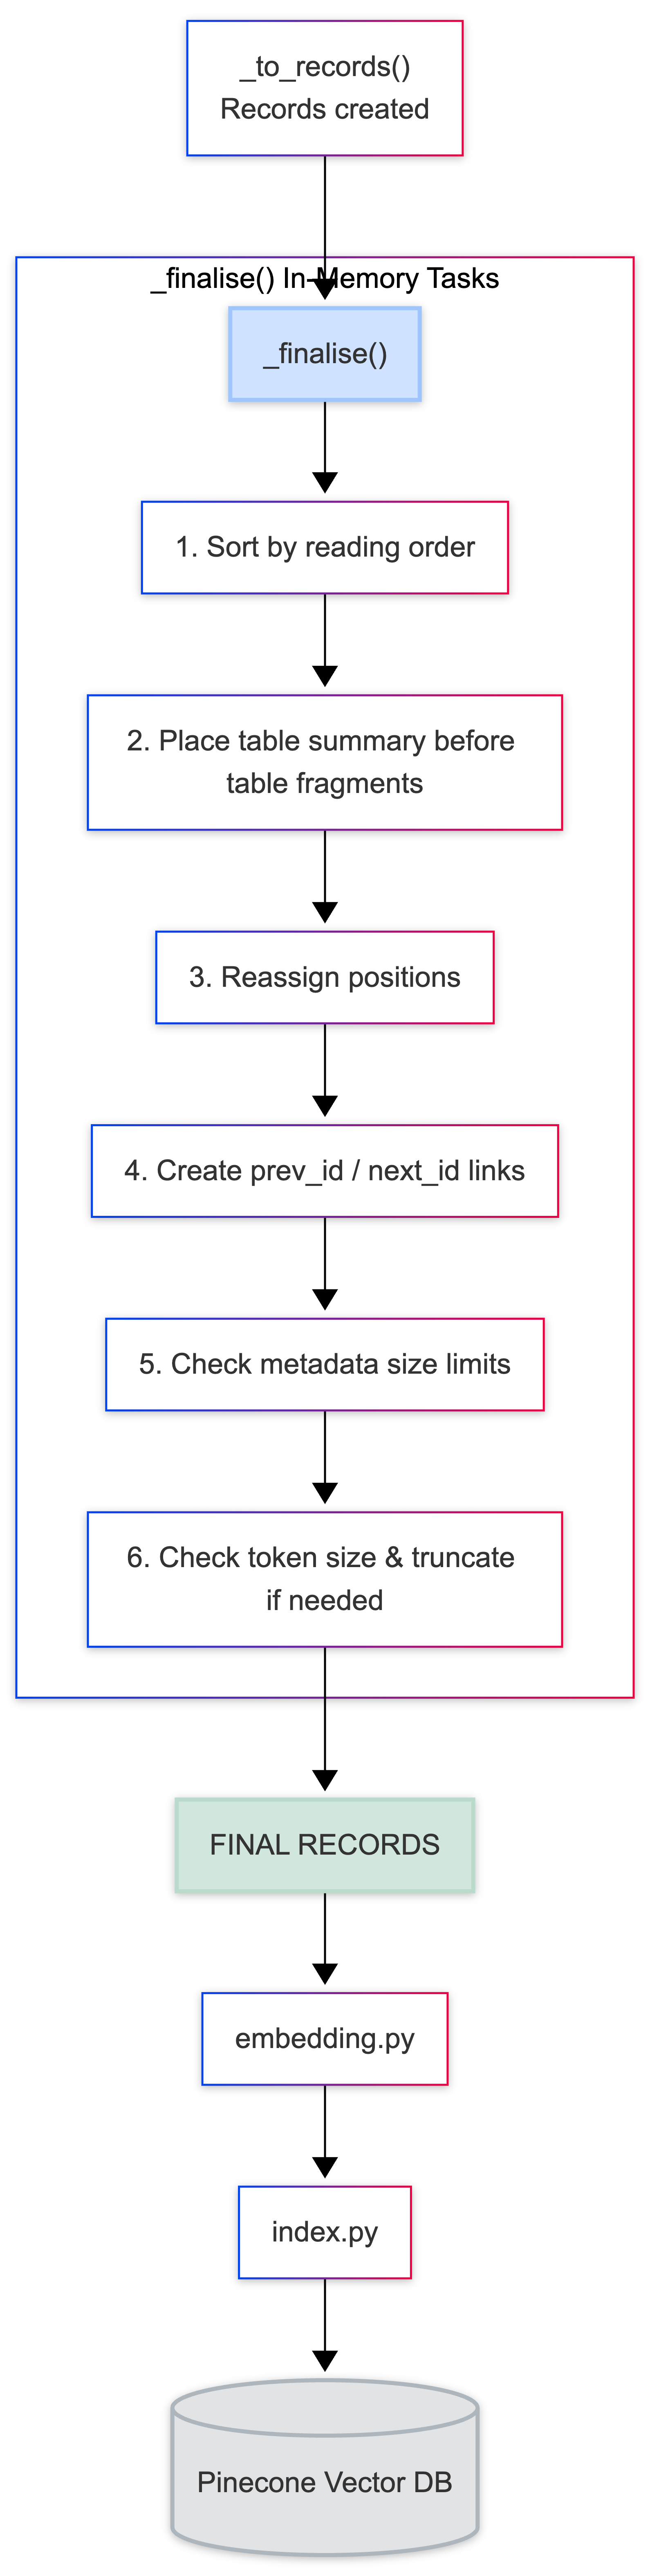

In [18]:
# Import the finalization pass.
from rag.chunking import _finalise

# Put all records into final reading order, add prev/next links,
# bound metadata size, and truncate only unsplittable oversized records.
records, truncated = _finalise(records)

| Stage | Input | What happens | Output |
|---|---|---|---|
| **clean_headings()** | Parsed document | Detects false SectionHeaderItems and demotes them to text before chunking | Cleaned document |
| **HybridChunker** | Cleaned document | Chunks document using document structure and token limits | Initial chunks |
| **_to_entries()** | HybridChunker chunks | Classifies content, removes page furniture, identifies figures | Normalized entries |
| **_merge_prose()** | Entries | Combines adjacent prose chunks belonging to the same heading path, subject to target size | Larger logical prose chunks |
| **_apply_floor()** | Entries | Prevents very small text chunks by absorbing them into the next text chunk; can cross heading boundaries | Minimum-sized entries |
| **_to_records()** | Entries | Converts entries into record dictionaries; expands figures and groups table fragments | Embedding-ready records |
| **_table_summaries()** | Table records | Creates one semantic/searchable summary per logical table | Table fragments + table summary |
| **_finalise()** | All records | Sorts records, assigns final positions, creates navigation links, enforces metadata/token limits | Final `records[]` |
| **embedding.py** | Final records | Takes each record’s text and converts it into a vector embedding | Vectors + record metadata |
| **index.py** | Embeddings + metadata | Prepares/upserts vectors into the vector database | Indexed vectors |
| **Pinecone** | Vectors + metadata | Stores and makes records searchable through vector similarity and metadata filtering | Searchable RAG knowledge base |

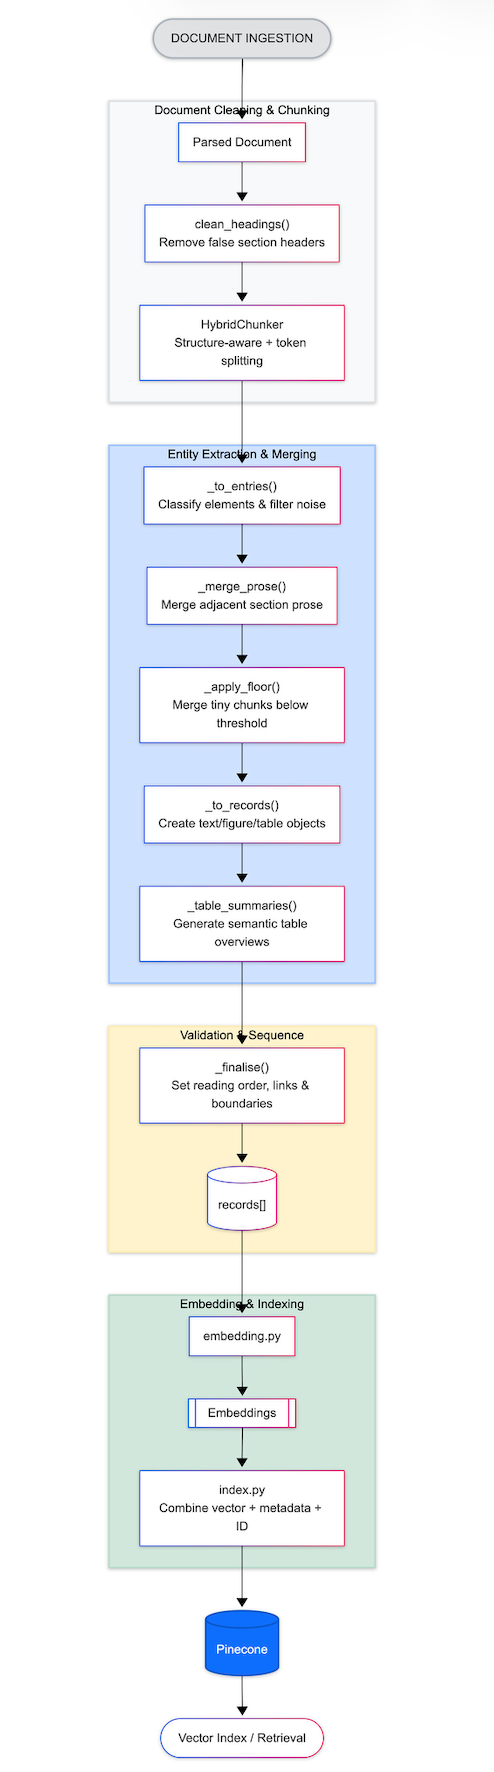
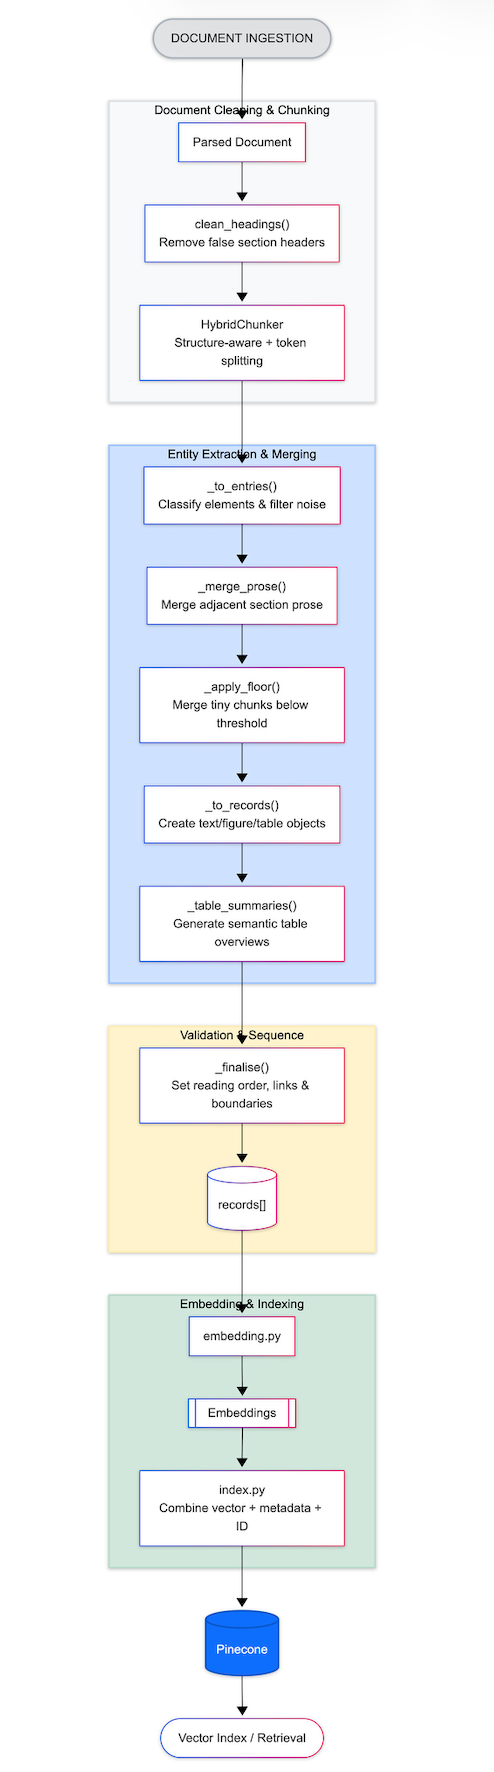

In [19]:
# Import the diagnostic reporting function.
from rag.chunking import _report

# Print a complete ingestion/chunking report.
# Combine statistics collected from the figure, table, furniture, prose-merge,
# minimum-floor, and truncation passes into one dictionary for reporting.
_report(
    records,
    chunks,
    tables,
    table_groups,
    {
        **fig_stats,
        **table_stats,
        "dropped": dropped,
        "merges": merges,
        "floor_merges": floor_merges,
        "truncated": truncated,
    },
)


  34 records from 80 chunks (3 of 3 tables summarised)
  types: {'text': 12, 'figure': 16, 'table_summary': 3, 'table': 3}
  size: median 224 tokens, 2 under 50, max 990
  dropped 20 chunk(s) as page furniture: {'a single glyph': 6, 'an attribution line': 14}
    p2 a single glyph: 'M'
    p2 an attribution line: 'Source: Morgan Stanley Research'
    p2 an attribution line: 'Source: Morgan Stanley Research'
    p3 a single glyph: 'M'
    p3 an attribution line: 'Source: FactSet, Morgan Stanley Research'
    p3 an attribution line: 'Source: FactSet, Morgan Stanley Research'
    p3 an attribution line: 'Source: FactSet, Morgan Stanley Research'
    p3 an attribution line: 'Source: FactSet, Morgan Stanley Research'
    p3 an attribution line: 'Source: FactSet, Morgan Stanley Research'
    p3 an attribution line: 'Source: FactSet, Morgan Stanley Research'
    p4 a single glyph: 'M'
    p5 a single glyph: 'M'
    p5 an attribution line: 'Source: Eikon, Morgan Stanley Research'
    p5 an att

In [ ]:
from rag import inspect as inspection
chunk_report = inspection.write_chunk_report(records, DOC_ID)

In [29]:
from rag import index as index_module
from rag import sync as sync_module

index = index_module.open_index(create=True)
plan = sync_module.sync(index, DOC_ID, records)

  {'indexed': 34, 'incoming': 34, 'added': 0, 'removed': 0, 'unchanged': 34, 'metadata_only': 0}
